# Gait Event Detection Pipeline
## Using Bitcn-Bigru-CrossAttention Algorithm

This notebook implements gait event detection for left and right gait events (Heel Strike, Toe Off)
using sensor data from multiple pathologies: HS, CVA, CIPN, PD, RIL

## 1. Import Libraries dan Setup

In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.keras)

2.21.0
<KerasLazyLoader>


In [2]:
import os
import json
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
import keras
from keras import layers, Model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Setup paths
WORKSPACE_ROOT = r'c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen'
DATASET_DIR = os.path.join(WORKSPACE_ROOT, 'dataset', 'dataset', 'data')
HEALTHY_HS_DIR = os.path.join(DATASET_DIR, 'healthy', 'HS')
NEURO_CIPN_DIR = os.path.join(DATASET_DIR, 'neuro', 'CIPN')
NEURO_CVA_DIR = os.path.join(DATASET_DIR, 'neuro', 'CVA')
NEURO_PD_DIR = os.path.join(DATASET_DIR, 'neuro', 'PD')
NEURO_RIL_DIR = os.path.join(DATASET_DIR, 'neuro', 'RIL')
OUTPUT_DIR = os.path.join(WORKSPACE_ROOT, 'results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Workspace Root: {WORKSPACE_ROOT}")
print(f"Dataset Dir: {DATASET_DIR}")
print(f"Output Dir: {OUTPUT_DIR}")

Workspace Root: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen
Dataset Dir: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\dataset\dataset\data
Output Dir: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\results


## 2. Data Extraction Function

In [3]:
def extract_subject_data(subject_dir):
    """
    Extract metadata, sensor data, and gait events from a subject directory.
    Returns list of trials with complete information.
    """
    trials_data = []
    
    # Iterate through trial folders (e.g., HS_1_1, HS_1_2, etc.)
    for trial_folder in os.listdir(subject_dir):
        trial_path = os.path.join(subject_dir, trial_folder)
        if not os.path.isdir(trial_path):
            continue
        
        # Load metadata
        meta_file = os.path.join(trial_path, f"{trial_folder}_meta.json")
        if not os.path.exists(meta_file):
            continue
        
        try:
            with open(meta_file, 'r') as f:
                meta = json.load(f)
        except Exception as e:
            print(f"Error loading {meta_file}: {e}")
            continue
        
        # Load sensor data
        sensor_file = os.path.join(trial_path, f"{trial_folder}_processed_data.txt")
        if not os.path.exists(sensor_file):
            continue
        
        try:
            sensor_df = pd.read_csv(sensor_file, sep=r'\s+')
        except Exception as e:
            print(f"Error loading {sensor_file}: {e}")
            continue
        
        # Extract LF and RF sensor columns
        sensor_cols_lfrf = ['LF_FreeAcc_X', 'LF_FreeAcc_Y', 'LF_FreeAcc_Z',
                            'LF_Gyr_X', 'LF_Gyr_Y', 'LF_Gyr_Z',
                            'RF_FreeAcc_X', 'RF_FreeAcc_Y', 'RF_FreeAcc_Z',
                            'RF_Gyr_X', 'RF_Gyr_Y', 'RF_Gyr_Z']
        
        sensor_cols_lflfrb = ['LF_FreeAcc_X', 'LF_FreeAcc_Y', 'LF_FreeAcc_Z',
                              'LF_Gyr_X', 'LF_Gyr_Y', 'LF_Gyr_Z',
                              'RF_FreeAcc_X', 'RF_FreeAcc_Y', 'RF_FreeAcc_Z',
                              'RF_Gyr_X', 'RF_Gyr_Y', 'RF_Gyr_Z',
                              'LB_FreeAcc_X', 'LB_FreeAcc_Y', 'LB_FreeAcc_Z',
                              'LB_Gyr_X', 'LB_Gyr_Y', 'LB_Gyr_Z']
        
        # Check which columns are available
        available_cols = sensor_df.columns.tolist()
        if all(col in available_cols for col in sensor_cols_lfrf):
            sensor_data = sensor_df[sensor_cols_lfrf].copy()
            sensor_config = 'LFRF'
        elif all(col in available_cols for col in sensor_cols_lflfrb):
            sensor_data = sensor_df[sensor_cols_lflfrb].copy()
            sensor_config = 'LFLFRB'
        else:
            print(f"Missing sensor columns in {trial_folder}")
            continue
        
        # Extract metadata features
        metadata = {
            'trial_id': trial_folder,
            'subject': meta.get('subject'),
            'pathology': meta.get('pathologyKey'),
            'age': meta.get('age'),
            'gender': meta.get('gender'),
            'height': meta.get('height'),
            'weight': meta.get('weight'),
            'bmi': meta.get('BMI'),
            'laterality': meta.get('laterality'),
            'deficit_side': meta.get('clinicalDeficitSide', 'None'),
            'fma_score': meta.get('evaluationScoreValue', 34.0 if meta.get('pathologyKey') == 'HS' else None),
            'freq': meta.get('freq', 100.0),
            'sensor_config': sensor_config,
            'left_gait_events': meta.get('leftGaitEvents', []),
            'right_gait_events': meta.get('rightGaitEvents', []),
            'uturn_boundaries': meta.get('uturnBoundaries', [])
        }
        
        trials_data.append({
            'metadata': metadata,
            'sensor_data': sensor_data,
            'sensor_matrix': sensor_data.values.astype(np.float32)
        })
    
    return trials_data

print("Extract function defined")

Extract function defined


## 3. Load Dataset dari Multiple Pathologies

In [4]:
def load_pathology_data(pathology_name, pathology_dir):
    """
    Load all subjects data from a specific pathology directory.
    """
    all_trials = []
    
    if not os.path.exists(pathology_dir):
        print(f"Directory not found: {pathology_dir}")
        return all_trials
    
    subject_folders = sorted([f for f in os.listdir(pathology_dir) 
                             if os.path.isdir(os.path.join(pathology_dir, f))])
    
    print(f"\nLoading {pathology_name}: {len(subject_folders)} subjects found")
    
    for subject_folder in subject_folders[:10]:  # Limit to first 10 for now
        subject_path = os.path.join(pathology_dir, subject_folder)
        trials = extract_subject_data(subject_path)
        all_trials.extend(trials)
        print(f"  {subject_folder}: {len(trials)} trials")
    
    print(f"Total trials from {pathology_name}: {len(all_trials)}")
    return all_trials

# Load data from each pathology
hs_data = load_pathology_data('Healthy (HS)', HEALTHY_HS_DIR)
cva_data = load_pathology_data('CVA (Cerebral Vascular Accident)', NEURO_CVA_DIR)
cipn_data = load_pathology_data('CIPN (Chemotherapy-Induced Peripheral Neuropathy)', NEURO_CIPN_DIR)
pd_data = load_pathology_data('PD (Parkinson Disease)', NEURO_PD_DIR)
ril_data = load_pathology_data('RIL (Rehabilitation in Stroke)', NEURO_RIL_DIR)

# Combine all data
all_dataset = hs_data + cva_data + cipn_data + pd_data + ril_data
print(f"\n=== Total dataset: {len(all_dataset)} trials ===")


Loading Healthy (HS): 73 subjects found
  HS_1: 5 trials
  HS_10: 5 trials
  HS_11: 5 trials
  HS_12: 5 trials
  HS_13: 5 trials
  HS_14: 4 trials
  HS_15: 5 trials
  HS_16: 5 trials
  HS_17: 5 trials
  HS_18: 5 trials
Total trials from Healthy (HS): 49

Loading CVA (Cerebral Vascular Accident): 49 subjects found
  CVA_1: 2 trials
  CVA_10: 2 trials
  CVA_11: 2 trials
  CVA_12: 4 trials
  CVA_13: 2 trials
  CVA_14: 2 trials
  CVA_15: 3 trials
  CVA_16: 2 trials
  CVA_17: 3 trials
  CVA_18: 2 trials
Total trials from CVA (Cerebral Vascular Accident): 24

Loading CIPN (Chemotherapy-Induced Peripheral Neuropathy): 19 subjects found
  CIPN_1: 5 trials
  CIPN_10: 5 trials
  CIPN_11: 5 trials
  CIPN_12: 5 trials
  CIPN_13: 4 trials
  CIPN_14: 5 trials
  CIPN_15: 5 trials
  CIPN_16: 5 trials
  CIPN_17: 5 trials
  CIPN_18: 5 trials
Total trials from CIPN (Chemotherapy-Induced Peripheral Neuropathy): 49

Loading PD (Parkinson Disease): 24 subjects found
  PD_1: 15 trials
  PD_10: 10 trials
  P

## 4. Data Preprocessing

In [5]:
def preprocess_sensor_data(sensor_matrix, window_size=100, stride=50):
    """
    Preprocess sensor data into windowed sequences.
    """
    sequences = []
    n_samples = len(sensor_matrix)
    
    for i in range(0, n_samples - window_size, stride):
        window = sensor_matrix[i:i+window_size]
        sequences.append(window)
    
    return np.array(sequences, dtype=np.float32)

def create_event_labels(left_events, right_events, data_length, window_size=100, stride=50):
    """
    Create binary labels for gait events (1 if event occurs in window, 0 otherwise).
    """
    labels_left = []
    labels_right = []
    
    n_windows = len(range(0, data_length - window_size, stride))
    
    for w_idx in range(n_windows):
        window_start = w_idx * stride
        window_end = window_start + window_size
        
        # Check if any left event overlaps with this window
        left_event = 0
        for [event_start, event_end] in left_events:
            if not (event_end < window_start or event_start > window_end):
                left_event = 1
                break
        
        # Check if any right event overlaps with this window
        right_event = 0
        for [event_start, event_end] in right_events:
            if not (event_end < window_start or event_start > window_end):
                right_event = 1
                break
        
        labels_left.append(left_event)
        labels_right.append(right_event)
    
    return np.array(labels_left), np.array(labels_right)

# Preprocess all data
X_data = []
y_left = []
y_right = []
metadata_list = []

print("\nPreprocessing sensor data...")
for trial_idx, trial in enumerate(all_dataset):
    sensor_matrix = trial['sensor_matrix']
    metadata = trial['metadata']
    
    # Create windowed sequences
    sequences = preprocess_sensor_data(sensor_matrix, window_size=100, stride=50)
    
    # Create event labels
    left_labels, right_labels = create_event_labels(
        metadata['left_gait_events'],
        metadata['right_gait_events'],
        len(sensor_matrix),
        window_size=100,
        stride=50
    )
    
    X_data.extend(sequences)
    y_left.extend(left_labels)
    y_right.extend(right_labels)
    
    for _ in range(len(sequences)):
        metadata_list.append(metadata)

X_data = np.array(X_data, dtype=np.float32)
y_left = np.array(y_left, dtype=np.int32)
y_right = np.array(y_right, dtype=np.int32)

print(f"Total sequences: {len(X_data)}")
print(f"X shape: {X_data.shape}")
print(f"y_left shape: {y_left.shape}")
print(f"y_right shape: {y_right.shape}")
print(f"Left events distribution: {np.bincount(y_left)}")
print(f"Right events distribution: {np.bincount(y_right)}")


Preprocessing sensor data...
Total sequences: 14711
X shape: (14711, 100, 12)
y_left shape: (14711,)
y_right shape: (14711,)
Left events distribution: [ 2320 12391]
Right events distribution: [ 2272 12439]


## 5. Build Bitcn-Bigru-CrossAttention Model

In [6]:
def build_bitcn_bigru_crossattention_model(input_shape):
    """
    Build BiTCN-BiGRU-CrossAttention model for gait event detection.
    
    Architecture:
    - Input: Time series sensor data
    - BiTCN (Bidirectional Temporal Convolutional Network)
    - BiGRU (Bidirectional Gated Recurrent Unit)
    - CrossAttention mechanism
    - Output: Binary classification for left and right gait events
    """
    
    # Input layer
    inputs = layers.Input(shape=input_shape, name='sensor_input')
    
    # BiTCN block - Bidirectional Temporal Convolutional Network
    # TCN forward
    tcn_forward = layers.Conv1D(64, 3, padding='same', activation='relu', name='tcn_conv1_f')(inputs)
    tcn_forward = layers.Dropout(0.3)(tcn_forward)
    tcn_forward = layers.Conv1D(64, 3, padding='same', activation='relu', name='tcn_conv2_f')(tcn_forward)
    tcn_forward = layers.MaxPooling1D(2)(tcn_forward)
    
    # TCN backward
    inputs_reversed = layers.Lambda(lambda x: tf.reverse(x, axis=[1]))(inputs)
    tcn_backward = layers.Conv1D(64, 3, padding='same', activation='relu', name='tcn_conv1_b')(inputs_reversed)
    tcn_backward = layers.Dropout(0.3)(tcn_backward)
    tcn_backward = layers.Conv1D(64, 3, padding='same', activation='relu', name='tcn_conv2_b')(tcn_backward)
    tcn_backward = layers.MaxPooling1D(2)(tcn_backward)
    tcn_backward = layers.Lambda(lambda x: tf.reverse(x, axis=[1]))(tcn_backward)
    
    # Concatenate BiTCN outputs
    bitcn_output = layers.Concatenate()([tcn_forward, tcn_backward])
    
    # BiGRU layer
    bigru = layers.Bidirectional(
        layers.GRU(64, return_sequences=True, dropout=0.2),
        name='bigru'
    )(bitcn_output)
    
    # Cross-Attention mechanism
    # Query, Key, Value from BiGRU output
    query = layers.Dense(64, name='attention_query')(bigru)
    key = layers.Dense(64, name='attention_key')(bigru)
    value = layers.Dense(64, name='attention_value')(bigru)
    
    # Attention scores
    attention_scores = layers.Dot(axes=[2, 2])([query, key])
    attention_scores = layers.Softmax(axis=-1)(attention_scores)
    attention_output = layers.Dot(axes=[2, 1])([attention_scores, value])
    
    # Combine attention output with BiGRU
    combined = layers.Concatenate()([bigru, attention_output])
    combined = layers.Dense(128, activation='relu')(combined)
    combined = layers.Dropout(0.3)(combined)
    
    # Global Average Pooling
    pooled = layers.GlobalAveragePooling1D()(combined)
    
    # Dense layers for classification
    dense1 = layers.Dense(64, activation='relu', name='dense1')(pooled)
    dense1 = layers.Dropout(0.3)(dense1)
    
    # Separate output heads for left and right events
    left_output = layers.Dense(1, activation='sigmoid', name='left_gait_event')(dense1)
    right_output = layers.Dense(1, activation='sigmoid', name='right_gait_event')(dense1)
    
    # Create model
    model = Model(inputs=inputs, outputs=[left_output, right_output])
    
    return model

# Build model
input_shape = (X_data.shape[1], X_data.shape[2])  # (sequence_length, n_features)
model = build_bitcn_bigru_crossattention_model(input_shape)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={'left_gait_event': 'binary_crossentropy', 'right_gait_event': 'binary_crossentropy'},
    metrics={'left_gait_event': 'accuracy', 'right_gait_event': 'accuracy'}
)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 100, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 100, 12)   │          0 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_conv1_b         │ (None, 100, 64)   │      2,368 │ lambda[0][0]      │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_conv1_f         │ (None, 100, 64)   │      2,368 │ sensor_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 100, 64)   │          0 │ tcn_conv1_b[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 100, 64)   │          0 │ tcn_conv1_f[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_conv2_b         │ (None, 100, 64)   │     12,352 │ dropout_1[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_conv2_f         │ (None, 100, 64)   │     12,352 │ dropout[0][0]     │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 50, 64)    │          0 │ tcn_conv2_b[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 50, 64)    │          0 │ tcn_conv2_f[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 50, 64)    │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 50, 128)   │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru               │ (None, 50, 128)   │     74,496 │ concatenate[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_query     │ (None, 50, 64)    │      8,256 │ bigru[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_key       │ (None, 50, 64)    │      8,256 │ bigru[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 50, 50)    │          0 │ attention_query[… │
│                     │                   │            │ attention_key[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 50, 50)    │          0 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_value     │ (None, 50, 64)    │      8,256 │ bigru[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 161,794 (632.01 KB)

 Trainable params: 161,794 (632.01 KB)

 Non-trainable params: 0 (0.00 B)

None


## 6. Train Model

In [7]:
# Split data
X_train, X_test, y_left_train, y_left_test, y_right_train, y_right_test = train_test_split(
    X_data, y_left, y_right, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Train model
history = model.fit(
    X_train,
    {'left_gait_event': y_left_train, 'right_gait_event': y_right_train},
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

print("\nTraining completed!")

Training set: (11768, 100, 12)
Test set: (2943, 100, 12)
Epoch 1/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - left_gait_event_accuracy: 0.8419 - left_gait_event_loss: 0.6374 - loss: 1.2768 - right_gait_event_accuracy: 0.8442 - right_gait_event_loss: 0.6391 - val_left_gait_event_accuracy: 0.8407 - val_left_gait_event_loss: 0.6074 - val_loss: 1.2143 - val_right_gait_event_accuracy: 0.8466 - val_right_gait_event_loss: 0.6067
Epoch 2/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - left_gait_event_accuracy: 0.8423 - left_gait_event_loss: 0.5753 - loss: 1.1504 - right_gait_event_accuracy: 0.8452 - right_gait_event_loss: 0.5750 - val_left_gait_event_accuracy: 0.8407 - val_left_gait_event_loss: 0.5479 - val_loss: 1.0935 - val_right_gait_event_accuracy: 0.8466 - val_right_gait_event_loss: 0.5453
Epoch 3/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - left_gait_event_accuracy: 0.8423 - left_gait_event_loss: 0.5260 - loss: 1.0499 - right_gait_event_accuracy: 0.8452 - right_gait_event_loss: 0.52

## 7. Evaluate Model

In [8]:
# Evaluate on test set
results = model.evaluate(X_test, {'left_gait_event': y_left_test, 'right_gait_event': y_right_test}, verbose=0)

print("\n=== Model Evaluation ===")
print(f"Test Loss: {results[0]:.4f}")
print(f"Left Event Accuracy: {results[1]:.4f}")
print(f"Right Event Accuracy: {results[2]:.4f}")

# Predictions on test set
y_pred_left, y_pred_right = model.predict(X_test)

# Convert to binary predictions
y_pred_left_binary = (y_pred_left > 0.5).astype(int).flatten()
y_pred_right_binary = (y_pred_right > 0.5).astype(int).flatten()

print(f"\nLeft predictions distribution: {np.bincount(y_pred_left_binary)}")
print(f"Right predictions distribution: {np.bincount(y_pred_right_binary)}")


=== Model Evaluation ===
Test Loss: 0.8635
Left Event Accuracy: 0.4334
Right Event Accuracy: 0.4300
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step

Left predictions distribution: [   0 2943]
Right predictions distribution: [   0 2943]


=== Model Evaluation Summary ===
Test loss: 0.8635
Left event accuracy: 0.4334
Right event accuracy: 0.4300

Left Event Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       460
           1     0.8437    1.0000    0.9152      2483

    accuracy                         0.8437      2943
   macro avg     0.4218    0.5000    0.4576      2943
weighted avg     0.7118    0.8437    0.7722      2943

Right Event Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       454
           1     0.8457    1.0000    0.9164      2489

    accuracy                         0.8457      2943
   macro avg     0.4229    0.5000    0.4582      2943
weighted avg     0.7153    0.8457    0.7751      2943

Saved evaluation plot to: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\results\gait_event_evaluation.png


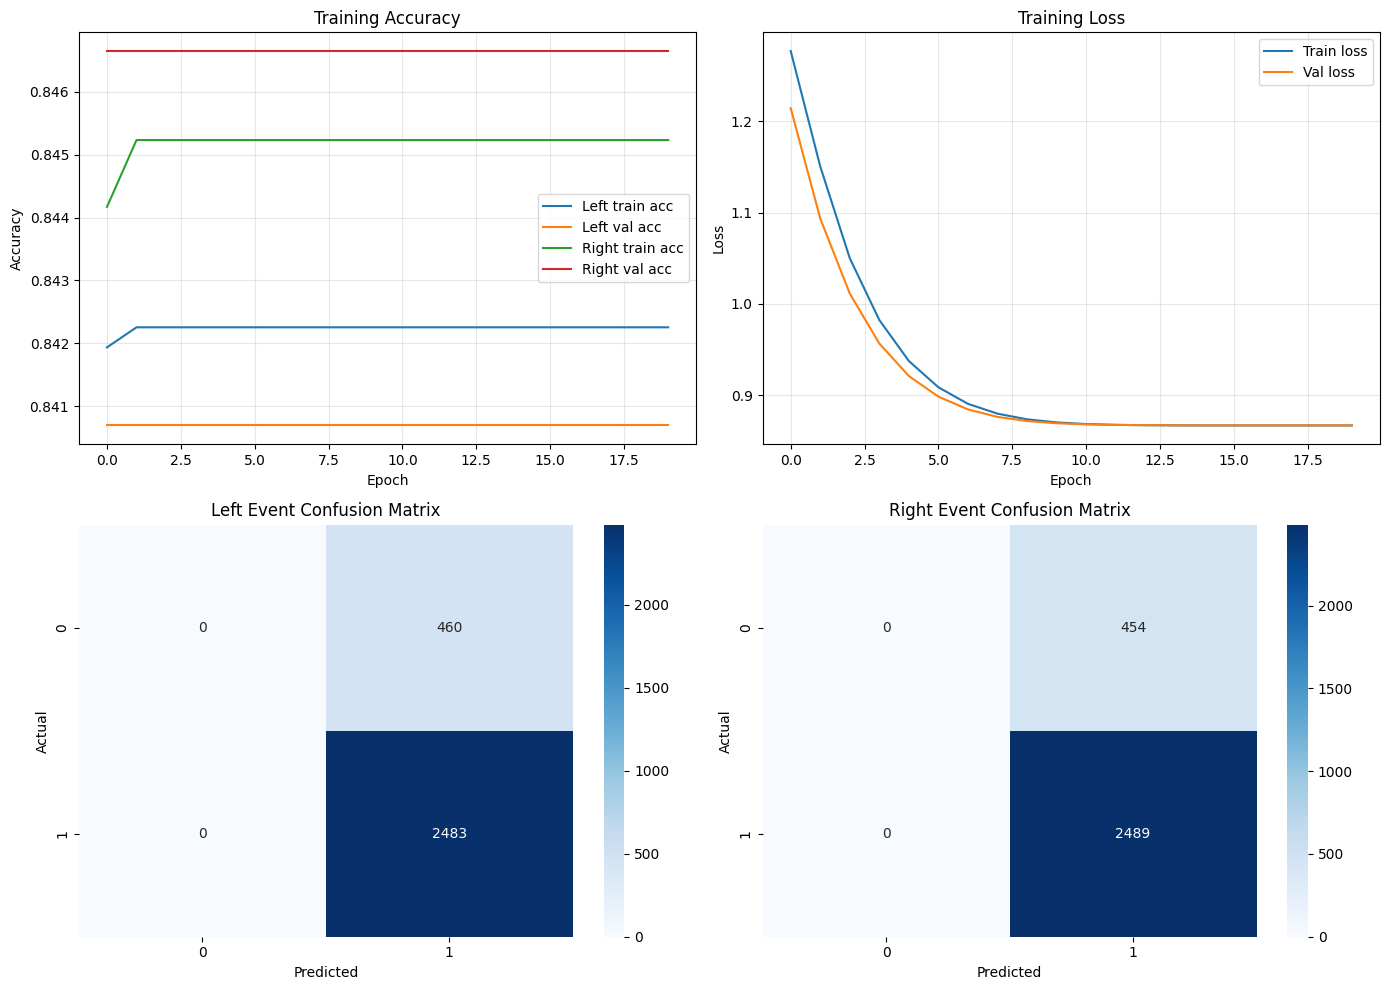

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

# Convert predicted probabilities to binary labels
y_pred_left_binary = (y_pred_left.flatten() > 0.5).astype(int)
y_pred_right_binary = (y_pred_right.flatten() > 0.5).astype(int)

print("=== Model Evaluation Summary ===")
if isinstance(results, (list, tuple)) and len(results) >= 3:
    print(f"Test loss: {results[0]:.4f}")
    print(f"Left event accuracy: {results[1]:.4f}")
    print(f"Right event accuracy: {results[2]:.4f}")

print("\nLeft Event Classification Report:")
print(classification_report(y_left_test, y_pred_left_binary, digits=4, zero_division=0))

print("Right Event Classification Report:")
print(classification_report(y_right_test, y_pred_right_binary, digits=4, zero_division=0))

cm_left = confusion_matrix(y_left_test, y_pred_left_binary)
cm_right = confusion_matrix(y_right_test, y_pred_right_binary)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if 'history' in globals() and history is not None:
    axes[0, 0].plot(history.history.get('left_gait_event_accuracy', []), label='Left train acc')
    axes[0, 0].plot(history.history.get('val_left_gait_event_accuracy', []), label='Left val acc')
    axes[0, 0].plot(history.history.get('right_gait_event_accuracy', []), label='Right train acc')
    axes[0, 0].plot(history.history.get('val_right_gait_event_accuracy', []), label='Right val acc')
    axes[0, 0].set_title('Training Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history.history.get('loss', []), label='Train loss')
    axes[0, 1].plot(history.history.get('val_loss', []), label='Val loss')
    axes[0, 1].set_title('Training Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, "No training history available", ha='center', va='center')
    axes[0, 0].set_axis_off()
    axes[0, 1].set_axis_off()

sns.heatmap(cm_left, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Left Event Confusion Matrix')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

sns.heatmap(cm_right, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Right Event Confusion Matrix')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
eval_plot_file = os.path.join(OUTPUT_DIR, 'gait_event_evaluation.png')
plt.savefig(eval_plot_file, dpi=150, bbox_inches='tight')
print(f"Saved evaluation plot to: {eval_plot_file}")
plt.show()



In [21]:
# Convert predicted probabilities to binary labels
y_pred_left_binary = (y_pred_left.flatten() > 0.5).astype(int)
y_pred_right_binary = (y_pred_right.flatten() > 0.5).astype(int)

# --- TAMBAHKAN KODE INI UNTUK CHECKING BENAR & SALAH ---
correct_left = (y_pred_left_binary == y_left_test).sum()
wrong_left = (y_pred_left_binary != y_left_test).sum()

correct_right = (y_pred_right_binary == y_right_test).sum()
wrong_right = (y_pred_right_binary != y_right_test).sum()

print("=== Hasil Checking Prediksi Dataset ===")
print(f"Left Event  -> Benar: {correct_left} dataset, Salah: {wrong_left} dataset")
print(f"Right Event -> Benar: {correct_right} dataset, Salah: {wrong_right} dataset")

# Pengecekan kondisi model
if wrong_left > 0 and len(np.unique(y_pred_left_binary)) == 1:
    print("\n[WARNING]: Model belum sesuai! Model hanya memprediksi satu kelas secara dominan.")
    print("Hal ini disebabkan oleh 'Class Imbalance' (Kelas 1 jauh lebih banyak dari kelas 0).")


=== Hasil Checking Prediksi Dataset ===
Left Event  -> Benar: 2483 dataset, Salah: 460 dataset
Right Event -> Benar: 2489 dataset, Salah: 454 dataset

[WARNING]: Model belum sesuai! Model hanya memprediksi satu kelas secara dominan.
Hal ini disebabkan oleh 'Class Imbalance' (Kelas 1 jauh lebih banyak dari kelas 0).


In [9]:
def detect_gait_events(sensor_matrix, model, window_size=100, stride=50, threshold=0.5):
    """
    Detect gait events from sensor data.
    Returns event boundaries in format [[start, end], [start, end], ...]
    """
    # Create sequences
    sequences = preprocess_sensor_data(sensor_matrix, window_size=window_size, stride=stride)
    
    if len(sequences) == 0:
        return [], []
    
    # Predict
    y_pred_left, y_pred_right = model.predict(sequences, verbose=0)
    
    # Convert to binary
    pred_left = (y_pred_left.flatten() > threshold).astype(int)
    pred_right = (y_pred_right.flatten() > threshold).astype(int)
    
    # Find event boundaries
    def find_events(predictions, stride, window_size):
        events = []
        in_event = False
        event_start = 0
        
        for idx, pred in enumerate(predictions):
            window_start = idx * stride
            
            if pred == 1 and not in_event:
                event_start = window_start
                in_event = True
            elif pred == 0 and in_event:
                event_end = window_start + window_size
                events.append([event_start, event_end])
                in_event = False
        
        # Handle case where event extends to end of data
        if in_event:
            event_end = len(predictions) * stride + window_size
            events.append([event_start, event_end])
        
        return events
    
    left_events = find_events(pred_left, stride, window_size)
    right_events = find_events(pred_right, stride, window_size)
    
    return left_events, right_events

print("Gait event detection function defined")

Gait event detection function defined


## 9. Generate Predictions on All Dataset

In [10]:
predictions_output = []

print("\nGenerating predictions on all dataset...")
for trial_idx, trial in enumerate(all_dataset):
    sensor_matrix = trial['sensor_matrix']
    metadata = trial['metadata']
    
    # Detect gait events
    left_events, right_events = detect_gait_events(sensor_matrix, model)
    
    # Prepare output
    output_entry = {
        'trial_id': metadata['trial_id'],
        'subject': metadata['subject'],
        'pathology': metadata['pathology'],
        'metadata': {
            'age': metadata['age'],
            'gender': metadata['gender'],
            'height': metadata['height'],
            'weight': metadata['weight'],
            'bmi': metadata['bmi'],
            'laterality': metadata['laterality'],
            'deficit_side': metadata['deficit_side'],
            'fma_score': metadata['fma_score'],
            'sensor_config': metadata['sensor_config']
        },
        'predictions': {
            'leftGaitEvents': left_events,
            'rightGaitEvents': right_events
        },
        'ground_truth': {
            'leftGaitEvents': metadata['left_gait_events'],
            'rightGaitEvents': metadata['right_gait_events']
        }
    }
    
    predictions_output.append(output_entry)
    
    if (trial_idx + 1) % 10 == 0:
        print(f"  Processed {trial_idx + 1} trials")

print(f"\nTotal predictions generated: {len(predictions_output)}")


Generating predictions on all dataset...
  Processed 10 trials
  Processed 20 trials
  Processed 30 trials
  Processed 40 trials
  Processed 50 trials
  Processed 60 trials
  Processed 70 trials
  Processed 80 trials
  Processed 90 trials
  Processed 100 trials
  Processed 110 trials
  Processed 120 trials
  Processed 130 trials
  Processed 140 trials
  Processed 150 trials
  Processed 160 trials
  Processed 170 trials
  Processed 180 trials
  Processed 190 trials
  Processed 200 trials
  Processed 210 trials
  Processed 220 trials
  Processed 230 trials
  Processed 240 trials
  Processed 250 trials
  Processed 260 trials

Total predictions generated: 264


## 10. Save Results to JSON

In [11]:
# Save all predictions
output_file = os.path.join(OUTPUT_DIR, 'gait_event_predictions.json')
with open(output_file, 'w') as f:
    json.dump(predictions_output, f, indent=2)

print(f"Predictions saved to: {output_file}")

# Save summary statistics
summary = {
    'total_trials': len(predictions_output),
    'pathologies': list(set([p['pathology'] for p in predictions_output])),
    'sensor_configs': list(set([p['metadata']['sensor_config'] for p in predictions_output])),
    'model_architecture': 'BiTCN-BiGRU-CrossAttention',
    'metrics': {
        'test_loss': float(results[0]),
        'left_event_accuracy': float(results[1]),
        'right_event_accuracy': float(results[2])
    }
}

summary_file = os.path.join(OUTPUT_DIR, 'summary.json')
with open(summary_file, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Summary saved to: {summary_file}")
print(f"\n{json.dumps(summary, indent=2)}")

Predictions saved to: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\results\gait_event_predictions.json
Summary saved to: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\results\summary.json

{
  "total_trials": 264,
  "pathologies": [
    "RIL",
    "HS",
    "CIPN",
    "CVA",
    "PD"
  ],
  "sensor_configs": [
    "LFRF"
  ],
  "model_architecture": "BiTCN-BiGRU-CrossAttention",
  "metrics": {
    "test_loss": 0.8635324239730835,
    "left_event_accuracy": 0.43344324827194214,
    "right_event_accuracy": 0.42996641993522644
  }
}


## 11. Visualization of Results

Plot saved to: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\results\gait_event_detection_sample.png


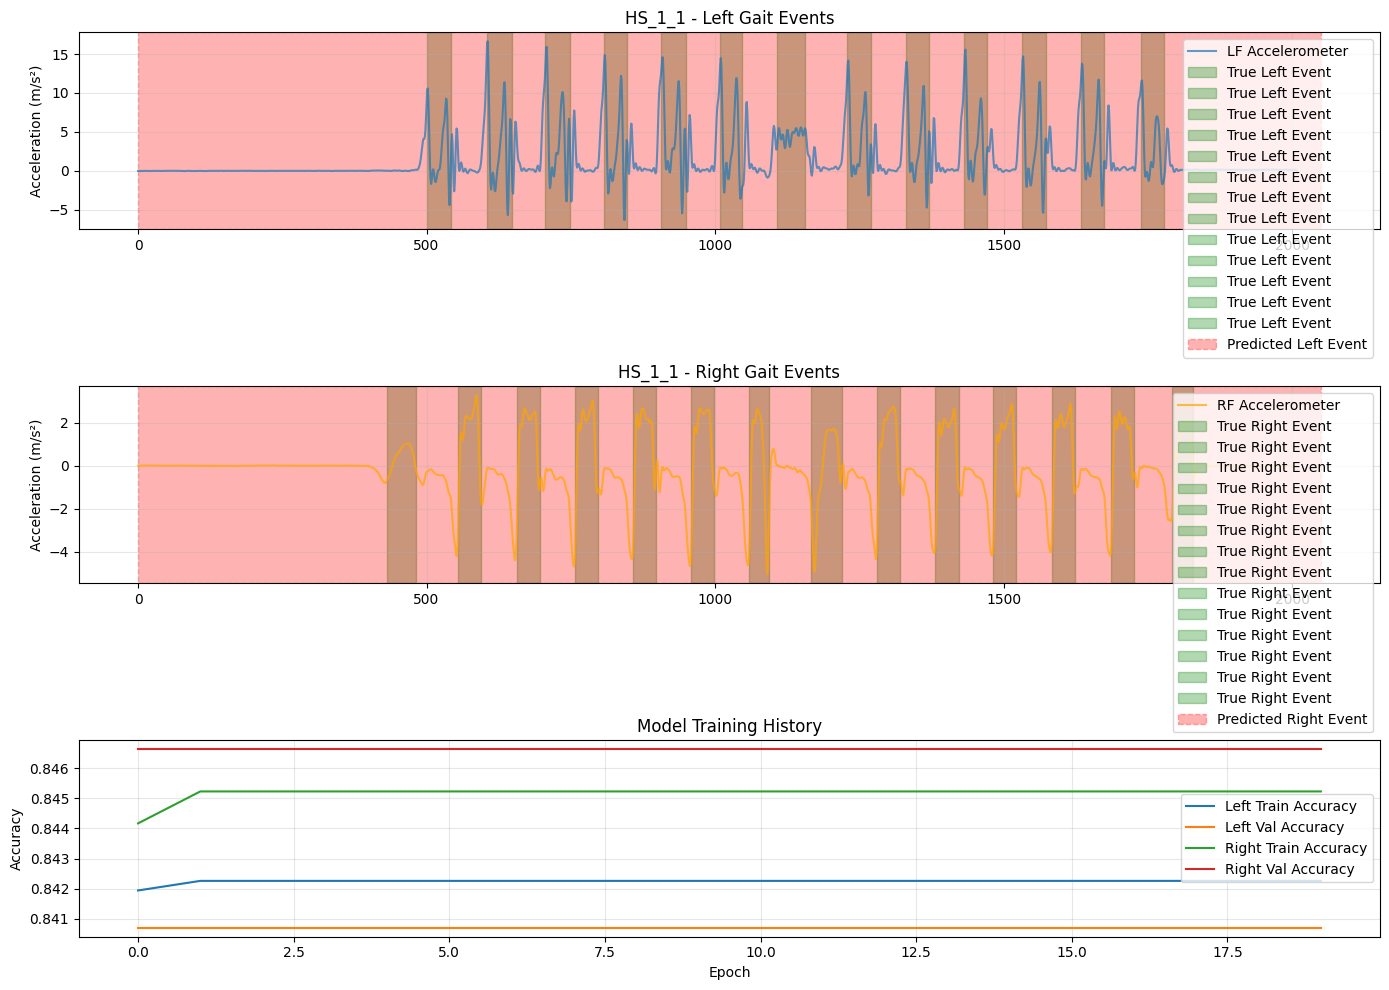

In [12]:
# Visualize sample predictions
sample_idx = 0
sample_trial = all_dataset[sample_idx]
sample_sensor = sample_trial['sensor_matrix']
sample_meta = sample_trial['metadata']

# Get predictions
pred_left_events, pred_right_events = detect_gait_events(sample_sensor, model)
true_left_events = sample_meta['left_gait_events']
true_right_events = sample_meta['right_gait_events']

# Plot sensor data with events
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot LF accelerometer
lf_acc = sample_sensor[:, [0, 1, 2]].mean(axis=1)
axes[0].plot(lf_acc, label='LF Accelerometer', alpha=0.7)

# Mark true left events
for event in true_left_events:
    axes[0].axvspan(event[0], event[1], alpha=0.3, color='green', label='True Left Event')

# Mark predicted left events
for event in pred_left_events:
    axes[0].axvspan(event[0], event[1], alpha=0.3, color='red', label='Predicted Left Event', linestyle='--')

axes[0].set_title(f'{sample_meta["trial_id"]} - Left Gait Events')
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot RF accelerometer
rf_acc = sample_sensor[:, [9, 10, 11]].mean(axis=1)
axes[1].plot(rf_acc, label='RF Accelerometer', alpha=0.7, color='orange')

# Mark true right events
for event in true_right_events:
    axes[1].axvspan(event[0], event[1], alpha=0.3, color='green', label='True Right Event')

# Mark predicted right events
for event in pred_right_events:
    axes[1].axvspan(event[0], event[1], alpha=0.3, color='red', label='Predicted Right Event', linestyle='--')

axes[1].set_title(f'{sample_meta["trial_id"]} - Right Gait Events')
axes[1].set_ylabel('Acceleration (m/s²)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Plot training history
if history is not None:
    axes[2].plot(history.history['left_gait_event_accuracy'], label='Left Train Accuracy')
    axes[2].plot(history.history['val_left_gait_event_accuracy'], label='Left Val Accuracy')
    axes[2].plot(history.history['right_gait_event_accuracy'], label='Right Train Accuracy')
    axes[2].plot(history.history['val_right_gait_event_accuracy'], label='Right Val Accuracy')
    axes[2].set_title('Model Training History')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plot_file = os.path.join(OUTPUT_DIR, 'gait_event_detection_sample.png')
plt.savefig(plot_file, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_file}")
plt.show()

## 12. Trial Error: Sensor Configuration Comparison

In [13]:
# Compare predictions for different sensor configurations
sensor_configs = {}

for pred in predictions_output:
    config = pred['metadata']['sensor_config']
    pathology = pred['pathology']
    
    key = f"{pathology}_{config}"
    
    if key not in sensor_configs:
        sensor_configs[key] = {
            'count': 0,
            'left_events_avg': 0,
            'right_events_avg': 0,
            'trials': []
        }
    
    sensor_configs[key]['count'] += 1
    sensor_configs[key]['left_events_avg'] += len(pred['predictions']['leftGaitEvents'])
    sensor_configs[key]['right_events_avg'] += len(pred['predictions']['rightGaitEvents'])
    sensor_configs[key]['trials'].append(pred['trial_id'])

# Calculate averages
for key in sensor_configs:
    count = sensor_configs[key]['count']
    sensor_configs[key]['left_events_avg'] /= count
    sensor_configs[key]['right_events_avg'] /= count

# Print comparison
print("\n=== Sensor Configuration Comparison ===")
print(f"{'Config':<30} {'Count':<8} {'Avg L Events':<15} {'Avg R Events':<15}")
print("-" * 68)

for config, data in sensor_configs.items():
    print(f"{config:<30} {data['count']:<8} {data['left_events_avg']:<15.2f} {data['right_events_avg']:<15.2f}")

# Save comparison
comparison_file = os.path.join(OUTPUT_DIR, 'sensor_config_comparison.json')
with open(comparison_file, 'w') as f:
    json.dump(sensor_configs, f, indent=2)

print(f"\nComparison saved to: {comparison_file}")


=== Sensor Configuration Comparison ===
Config                         Count    Avg L Events    Avg R Events   
--------------------------------------------------------------------
HS_LFRF                        49       1.00            1.00           
CVA_LFRF                       24       1.00            1.00           
CIPN_LFRF                      49       1.00            1.00           
PD_LFRF                        75       1.00            1.00           
RIL_LFRF                       67       1.00            1.00           

Comparison saved to: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\results\sensor_config_comparison.json


## 13. Trial Error Analysis: Different Pathology Combinations

In [14]:
# Analyze predictions by pathology combination
pathology_analysis = {}

for pred in predictions_output:
    pathology = pred['pathology']
    
    if pathology not in pathology_analysis:
        pathology_analysis[pathology] = {
            'count': 0,
            'avg_left_events': 0,
            'avg_right_events': 0,
            'metadata_features': {
                'age': [],
                'height': [],
                'weight': [],
                'bmi': []
            }
        }
    
    pathology_analysis[pathology]['count'] += 1
    pathology_analysis[pathology]['avg_left_events'] += len(pred['predictions']['leftGaitEvents'])
    pathology_analysis[pathology]['avg_right_events'] += len(pred['predictions']['rightGaitEvents'])
    
    # Collect metadata
    for key in pathology_analysis[pathology]['metadata_features']:
        val = pred['metadata'].get(key)
        if val is not None:
            pathology_analysis[pathology]['metadata_features'][key].append(val)

# Calculate statistics
for pathology in pathology_analysis:
    count = pathology_analysis[pathology]['count']
    pathology_analysis[pathology]['avg_left_events'] /= count
    pathology_analysis[pathology]['avg_right_events'] /= count
    
    for key in pathology_analysis[pathology]['metadata_features']:
        vals = pathology_analysis[pathology]['metadata_features'][key]
        if vals:
            pathology_analysis[pathology]['metadata_features'][key] = {
                'mean': float(np.mean(vals)),
                'std': float(np.std(vals))
            }

# Print analysis
print("\n=== Pathology Analysis ===")
print(f"{'Pathology':<15} {'Count':<10} {'Avg L Ev':<12} {'Avg R Ev':<12} {'Avg Age':<10}")
print("-" * 59)

for pathology, data in pathology_analysis.items():
    age_mean = data['metadata_features']['age'].get('mean', 0) if isinstance(data['metadata_features']['age'], dict) else 0
    print(f"{pathology:<15} {data['count']:<10} {data['avg_left_events']:<12.2f} {data['avg_right_events']:<12.2f} {age_mean:<10.1f}")

# Save analysis
analysis_file = os.path.join(OUTPUT_DIR, 'pathology_analysis.json')
with open(analysis_file, 'w') as f:
    json.dump(pathology_analysis, f, indent=2)

print(f"\nAnalysis saved to: {analysis_file}")


=== Pathology Analysis ===
Pathology       Count      Avg L Ev     Avg R Ev     Avg Age   
-----------------------------------------------------------
HS              49         1.00         1.00         25.9      
CVA             24         1.00         1.00         57.7      
CIPN            49         1.00         1.00         61.5      
PD              75         1.00         1.00         68.7      
RIL             67         1.00         1.00         64.1      

Analysis saved to: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\results\pathology_analysis.json


## 14. Save Model

In [15]:
# Save model
model_file = os.path.join(OUTPUT_DIR, 'bitcn_bigru_crossattention_model.h5')
model.save(model_file)

print(f"Model saved to: {model_file}")
print(f"\n=== Pipeline Complete ===")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Files generated:")
print(f"  - gait_event_predictions.json")
print(f"  - summary.json")
print(f"  - sensor_config_comparison.json")
print(f"  - pathology_analysis.json")
print(f"  - gait_event_detection_sample.png")
print(f"  - bitcn_bigru_crossattention_model.h5")

Model saved to: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\results\bitcn_bigru_crossattention_model.h5

=== Pipeline Complete ===
Output directory: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\results
Files generated:
  - gait_event_predictions.json
  - summary.json
  - sensor_config_comparison.json
  - pathology_analysis.json
  - gait_event_detection_sample.png
  - bitcn_bigru_crossattention_model.h5


Memvisualisasi trial #260:
  ID      : RIL_18_2
  Subject : RIL_18
  Patologi: RIL
  Jumlah sampel: 3450
  GT Left events : 20
  GT Right events: 21
Plot disimpan ke: c:\Users\fizel\OneDrive\Documents\Gait Analysis Event_Propen\results\gait_event_viz_trial_260.png


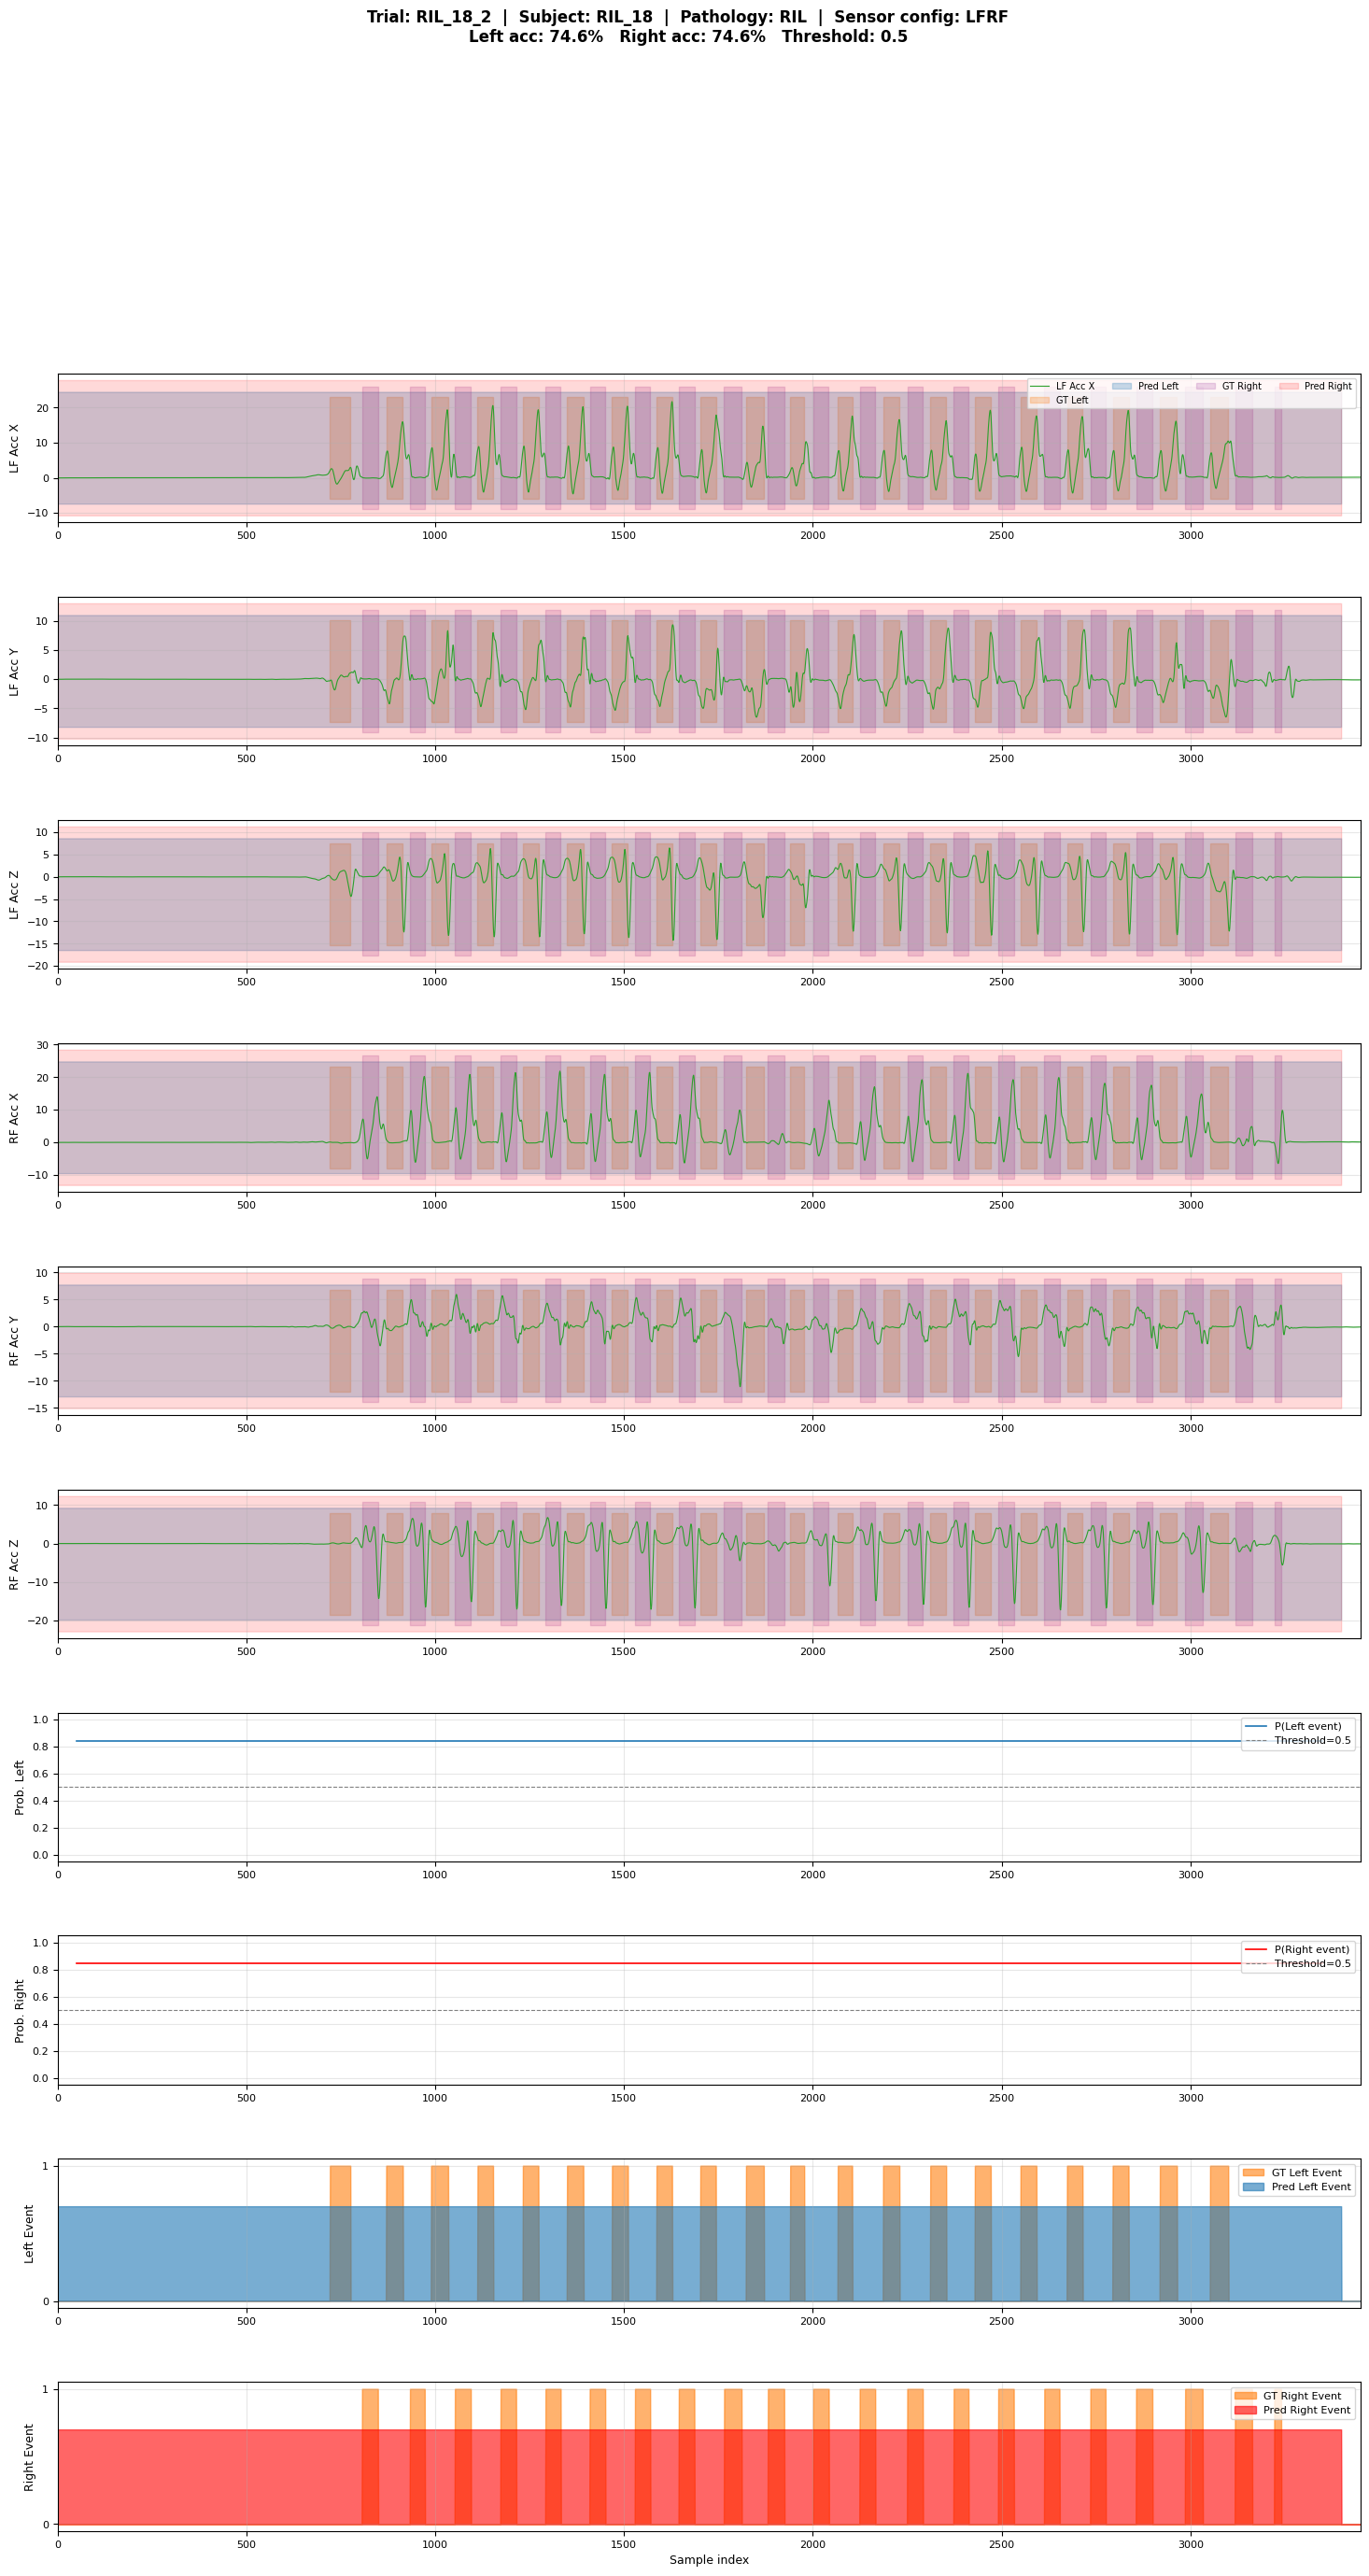


=== Summary Prediksi per Trial ===
Trial                Patologi   Acc L%   Acc R%
--------------------------------------------------
HS_1_1               HS          69.2%    76.9%
HS_1_2               HS          70.0%    75.0%
HS_1_3               HS          75.0%    75.0%
HS_1_4               HS          81.1%    75.7%
HS_1_5               HS          81.1%    75.7%
HS_10_1              HS          80.5%    70.7%
HS_10_2              HS          89.3%    89.3%
HS_10_3              HS          86.7%    83.3%
HS_10_4              HS          89.7%    86.2%
HS_10_5              HS          86.7%    83.3%
HS_11_1              HS          73.2%    73.2%
HS_11_2              HS          69.0%    71.4%
HS_11_3              HS          76.9%    76.9%
HS_11_4              HS          65.9%    75.6%
HS_11_5              HS          80.6%    83.3%
HS_12_1              HS          69.8%    74.4%
HS_12_2              HS          76.7%    76.7%
HS_12_3              HS          70.5%    77.3%
H

In [25]:
"""
=============================================================
 VISUALISASI PREDIKSI GAIT EVENT (Left & Right)
=============================================================
Salin dan tempel kode berikut ke dalam cell baru di notebook Anda.
Pastikan model sudah dilatih dan variable `all_dataset`, `model` sudah ada.
=============================================================
"""

# ──────────────────────────────────────────────────────────
# CELL: VISUALISASI PREDIKSI GAIT EVENT
# ──────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ─── CONFIG ───────────────────────────────────────────────
WINDOW_SIZE   = 100          # harus sama dengan saat training
STRIDE        = 50           # harus sama dengan saat training
THRESHOLD     = 0.5          # batas binarisasi prediksi

# Pilih trial yang ingin divisualisasi (index dari all_dataset)
# Ganti angka ini untuk melihat trial lain
TRIAL_INDEX   = 260

# Kanal sinyal sensor yang ditampilkan di grafik
# Sesuaikan dengan kolom yang ada di data Anda
SIGNAL_CHANNELS = {
    "LF Acc X":  0,   # LF_FreeAcc_X
    "LF Acc Y":  1,   # LF_FreeAcc_Y
    "LF Acc Z":  2,   # LF_FreeAcc_Z
    "RF Acc X":  6,   # RF_FreeAcc_X
    "RF Acc Y":  7,   # RF_FreeAcc_Y
    "RF Acc Z":  8,   # RF_FreeAcc_Z
}
# ──────────────────────────────────────────────────────────


# ─── FUNGSI BANTU ─────────────────────────────────────────

def predict_events(sensor_matrix, model, window_size=WINDOW_SIZE,
                   stride=STRIDE, threshold=THRESHOLD):
    """
    Jalankan model pada sensor_matrix dan kembalikan:
      - left_binary  : array biner per window (1 = ada event Left)
      - right_binary : array biner per window (1 = ada event Right)
      - prob_left    : probabilitas raw per window
      - prob_right   : probabilitas raw per window
    """
    sequences = []
    n = len(sensor_matrix)
    for i in range(0, n - window_size, stride):
        sequences.append(sensor_matrix[i:i + window_size])

    if len(sequences) == 0:
        return [], [], [], []

    sequences = np.array(sequences, dtype=np.float32)
    prob_left, prob_right = model.predict(sequences, verbose=0)

    prob_left  = prob_left.flatten()
    prob_right = prob_right.flatten()

    left_binary  = (prob_left  > threshold).astype(int)
    right_binary = (prob_right > threshold).astype(int)

    return left_binary, right_binary, prob_left, prob_right


def windows_to_sample_mask(binary_array, n_samples,
                            window_size=WINDOW_SIZE, stride=STRIDE):
    """
    Konversi label per-window ke label per-sample (voting majority / OR).
    Setiap sample diberi label 1 jika setidaknya satu window yang
    mencakupnya diprediksi positif.
    """
    mask = np.zeros(n_samples, dtype=int)
    for w_idx, val in enumerate(binary_array):
        if val == 1:
            start = w_idx * stride
            end   = min(start + window_size, n_samples)
            mask[start:end] = 1
    return mask


def event_intervals_to_mask(events, n_samples):
    """
    Konversi daftar [start, end] ke array biner per sample.
    """
    mask = np.zeros(n_samples, dtype=int)
    for ev in events:
        s, e = int(ev[0]), int(ev[1])
        s = max(0, s)
        e = min(n_samples, e)
        mask[s:e] = 1
    return mask


def plot_gait_events(trial, model,
                     window_size=WINDOW_SIZE,
                     stride=STRIDE,
                     threshold=THRESHOLD,
                     signal_channels=SIGNAL_CHANNELS,
                     save_path=None):
    """
    Plot lengkap visualisasi prediksi gait event untuk satu trial.

    Parameters
    ----------
    trial         : dict dengan key 'sensor_matrix', 'metadata'
    model         : model Keras yang sudah dilatih
    window_size   : panjang window
    stride        : langkah sliding window
    threshold     : ambang batas prediksi
    signal_channels : dict {label: kolom_index}
    save_path     : path file jika ingin disimpan (None = tampilkan saja)
    """

    sensor_matrix = trial['sensor_matrix']
    metadata      = trial['metadata']
    n_samples     = len(sensor_matrix)
    time_axis     = np.arange(n_samples)

    # ── Prediksi ─────────────────────────────────────────
    left_bin, right_bin, prob_l, prob_r = predict_events(
        sensor_matrix, model, window_size, stride, threshold
    )

    # Konversi ke level sample
    pred_left_mask  = windows_to_sample_mask(left_bin,  n_samples, window_size, stride)
    pred_right_mask = windows_to_sample_mask(right_bin, n_samples, window_size, stride)

    # Ground truth
    gt_left_mask  = event_intervals_to_mask(metadata.get('left_gait_events',  []), n_samples)
    gt_right_mask = event_intervals_to_mask(metadata.get('right_gait_events', []), n_samples)

    # ── Hitung metrik sederhana ───────────────────────────
    n_windows   = len(left_bin)
    gt_l_win    = []
    gt_r_win    = []
    for w in range(n_windows):
        ws = w * stride
        we = ws + window_size
        gl = int(np.any(gt_left_mask[ws:we]  == 1))
        gr = int(np.any(gt_right_mask[ws:we] == 1))
        gt_l_win.append(gl)
        gt_r_win.append(gr)

    acc_l = np.mean(np.array(gt_l_win)  == left_bin)  * 100
    acc_r = np.mean(np.array(gt_r_win)  == right_bin) * 100

    # ── Layout ───────────────────────────────────────────
    n_signal_rows = len(signal_channels)
    # Baris: sinyal sensor × n, probabilitas kiri, probabilitas kanan,
    #        event kiri vs GT, event kanan vs GT
    n_rows = n_signal_rows + 4
    fig = plt.figure(figsize=(18, 3 * n_rows))
    gs  = GridSpec(n_rows, 1, figure=fig, hspace=0.5)

    title = (
        f"Trial: {metadata.get('trial_id','?')}  |  "
        f"Subject: {metadata.get('subject','?')}  |  "
        f"Pathology: {metadata.get('pathology','?')}  |  "
        f"Sensor config: {metadata.get('sensor_config','?')}\n"
        f"Left acc: {acc_l:.1f}%   Right acc: {acc_r:.1f}%   "
        f"Threshold: {threshold}"
    )
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.01)

    color_pred = '#1f77b4'   # biru
    color_gt   = '#ff7f0e'   # oranye
    color_sig  = '#2ca02c'   # hijau

    row = 0

    # ── (1) Sinyal sensor ─────────────────────────────────
    for ch_label, ch_idx in signal_channels.items():
        ax = fig.add_subplot(gs[row])
        ax.plot(time_axis, sensor_matrix[:, ch_idx],
                color=color_sig, linewidth=0.8, label=ch_label)

        # Overlay: ground truth (kuning transparan) & prediksi (biru transparan)
        ax.fill_between(time_axis, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=(gt_left_mask == 1),
                        alpha=0.25, color=color_gt,   label='GT Left')
        ax.fill_between(time_axis, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=(pred_left_mask == 1),
                        alpha=0.25, color=color_pred, label='Pred Left')
        ax.fill_between(time_axis, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=(gt_right_mask == 1),
                        alpha=0.15, color='purple',   label='GT Right')
        ax.fill_between(time_axis, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=(pred_right_mask == 1),
                        alpha=0.15, color='red',      label='Pred Right')

        ax.set_ylabel(ch_label, fontsize=9)
        ax.set_xlim(0, n_samples)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.legend(loc='upper right', fontsize=7, ncol=4)
        row += 1

    # ── (2) Probabilitas Left ─────────────────────────────
    ax2 = fig.add_subplot(gs[row])
    window_centers = [w * stride + window_size // 2 for w in range(len(prob_l))]
    ax2.plot(window_centers, prob_l, color=color_pred,
             linewidth=1.2, label='P(Left event)')
    ax2.axhline(threshold, color='gray', linestyle='--', linewidth=0.8,
                label=f'Threshold={threshold}')
    ax2.set_ylabel('Prob. Left', fontsize=9)
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_xlim(0, n_samples)
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(labelsize=8)
    row += 1

    # ── (3) Probabilitas Right ────────────────────────────
    ax3 = fig.add_subplot(gs[row])
    ax3.plot(window_centers, prob_r, color='red',
             linewidth=1.2, label='P(Right event)')
    ax3.axhline(threshold, color='gray', linestyle='--', linewidth=0.8,
                label=f'Threshold={threshold}')
    ax3.set_ylabel('Prob. Right', fontsize=9)
    ax3.set_ylim(-0.05, 1.05)
    ax3.set_xlim(0, n_samples)
    ax3.legend(loc='upper right', fontsize=8)
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(labelsize=8)
    row += 1

    # ── (4) Perbandingan Left Event: GT vs Prediksi ───────
    ax4 = fig.add_subplot(gs[row])
    ax4.fill_between(time_axis, 0, gt_left_mask,
                     alpha=0.6, color=color_gt,   label='GT Left Event')
    ax4.fill_between(time_axis, 0, pred_left_mask * 0.7,
                     alpha=0.6, color=color_pred, label='Pred Left Event')
    ax4.set_ylabel('Left Event', fontsize=9)
    ax4.set_yticks([0, 1])
    ax4.set_xlim(0, n_samples)
    ax4.legend(loc='upper right', fontsize=8)
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(labelsize=8)
    row += 1

    # ── (5) Perbandingan Right Event: GT vs Prediksi ──────
    ax5 = fig.add_subplot(gs[row])
    ax5.fill_between(time_axis, 0, gt_right_mask,
                     alpha=0.6, color=color_gt,   label='GT Right Event')
    ax5.fill_between(time_axis, 0, pred_right_mask * 0.7,
                     alpha=0.6, color='red',       label='Pred Right Event')
    ax5.set_ylabel('Right Event', fontsize=9)
    ax5.set_xlabel('Sample index', fontsize=9)
    ax5.set_yticks([0, 1])
    ax5.set_xlim(0, n_samples)
    ax5.legend(loc='upper right', fontsize=8)
    ax5.grid(True, alpha=0.3)
    ax5.tick_params(labelsize=8)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Plot disimpan ke: {save_path}")
    plt.show()
    return fig


# ─── JALANKAN VISUALISASI ─────────────────────────────────

# Tampilkan satu trial
trial = all_dataset[TRIAL_INDEX]
print(f"Memvisualisasi trial #{TRIAL_INDEX}:")
print(f"  ID      : {trial['metadata'].get('trial_id','?')}")
print(f"  Subject : {trial['metadata'].get('subject','?')}")
print(f"  Patologi: {trial['metadata'].get('pathology','?')}")
print(f"  Jumlah sampel: {len(trial['sensor_matrix'])}")
print(f"  GT Left events : {len(trial['metadata'].get('left_gait_events',[]))}")
print(f"  GT Right events: {len(trial['metadata'].get('right_gait_events',[]))}")

save_file = os.path.join(OUTPUT_DIR, f"gait_event_viz_trial_{TRIAL_INDEX}.png")
plot_gait_events(trial, model, save_path=save_file)


# ─── LOOP: VISUALISASI SEMUA TRIAL (opsional) ─────────────
# Hapus komentar di bawah ini jika ingin memplot semua trial

# for idx, trial in enumerate(all_dataset):
#     save_path = os.path.join(OUTPUT_DIR, f"viz_trial_{idx:03d}.png")
#     plot_gait_events(trial, model, save_path=save_path)
#     print(f"Saved {save_path}")


# ─── SUMMARY STATISTIK PREDIKSI ───────────────────────────

print("\n=== Summary Prediksi per Trial ===")
print(f"{'Trial':<20} {'Patologi':<8} {'Acc L%':>8} {'Acc R%':>8}")
print("-" * 50)
for idx, trial in enumerate(all_dataset[:20]):   # tampilkan 20 pertama
    sm   = trial['sensor_matrix']
    meta = trial['metadata']
    n    = len(sm)

    lb, rb, _, _ = predict_events(sm, model)
    gt_lm = event_intervals_to_mask(meta.get('left_gait_events',  []), n)
    gt_rm = event_intervals_to_mask(meta.get('right_gait_events', []), n)

    nw    = len(lb)
    stride_val = STRIDE
    wsize = WINDOW_SIZE
    gl_w  = [int(np.any(gt_lm[w*stride_val:w*stride_val+wsize]==1)) for w in range(nw)]
    gr_w  = [int(np.any(gt_rm[w*stride_val:w*stride_val+wsize]==1)) for w in range(nw)]

    al = np.mean(np.array(gl_w) == lb) * 100 if nw > 0 else 0
    ar = np.mean(np.array(gr_w) == rb) * 100 if nw > 0 else 0

    print(f"{meta.get('trial_id','?'):<20} {meta.get('pathology','?'):<8} {al:>7.1f}% {ar:>7.1f}%")


Trial     : HS_1_1
Subject   : HS_1
Pathology : HS
N samples : 2009
GT Left   : 13 events
GT Right  : 14 events

[LF] Prediksi — Toe Off: 1, Heel Strike: 1
[LF] GT       — Toe Off: 13,   Heel Strike: 13
[RF] Prediksi — Toe Off: 1, Heel Strike: 1
[RF] GT       — Toe Off: 14,   Heel Strike: 14


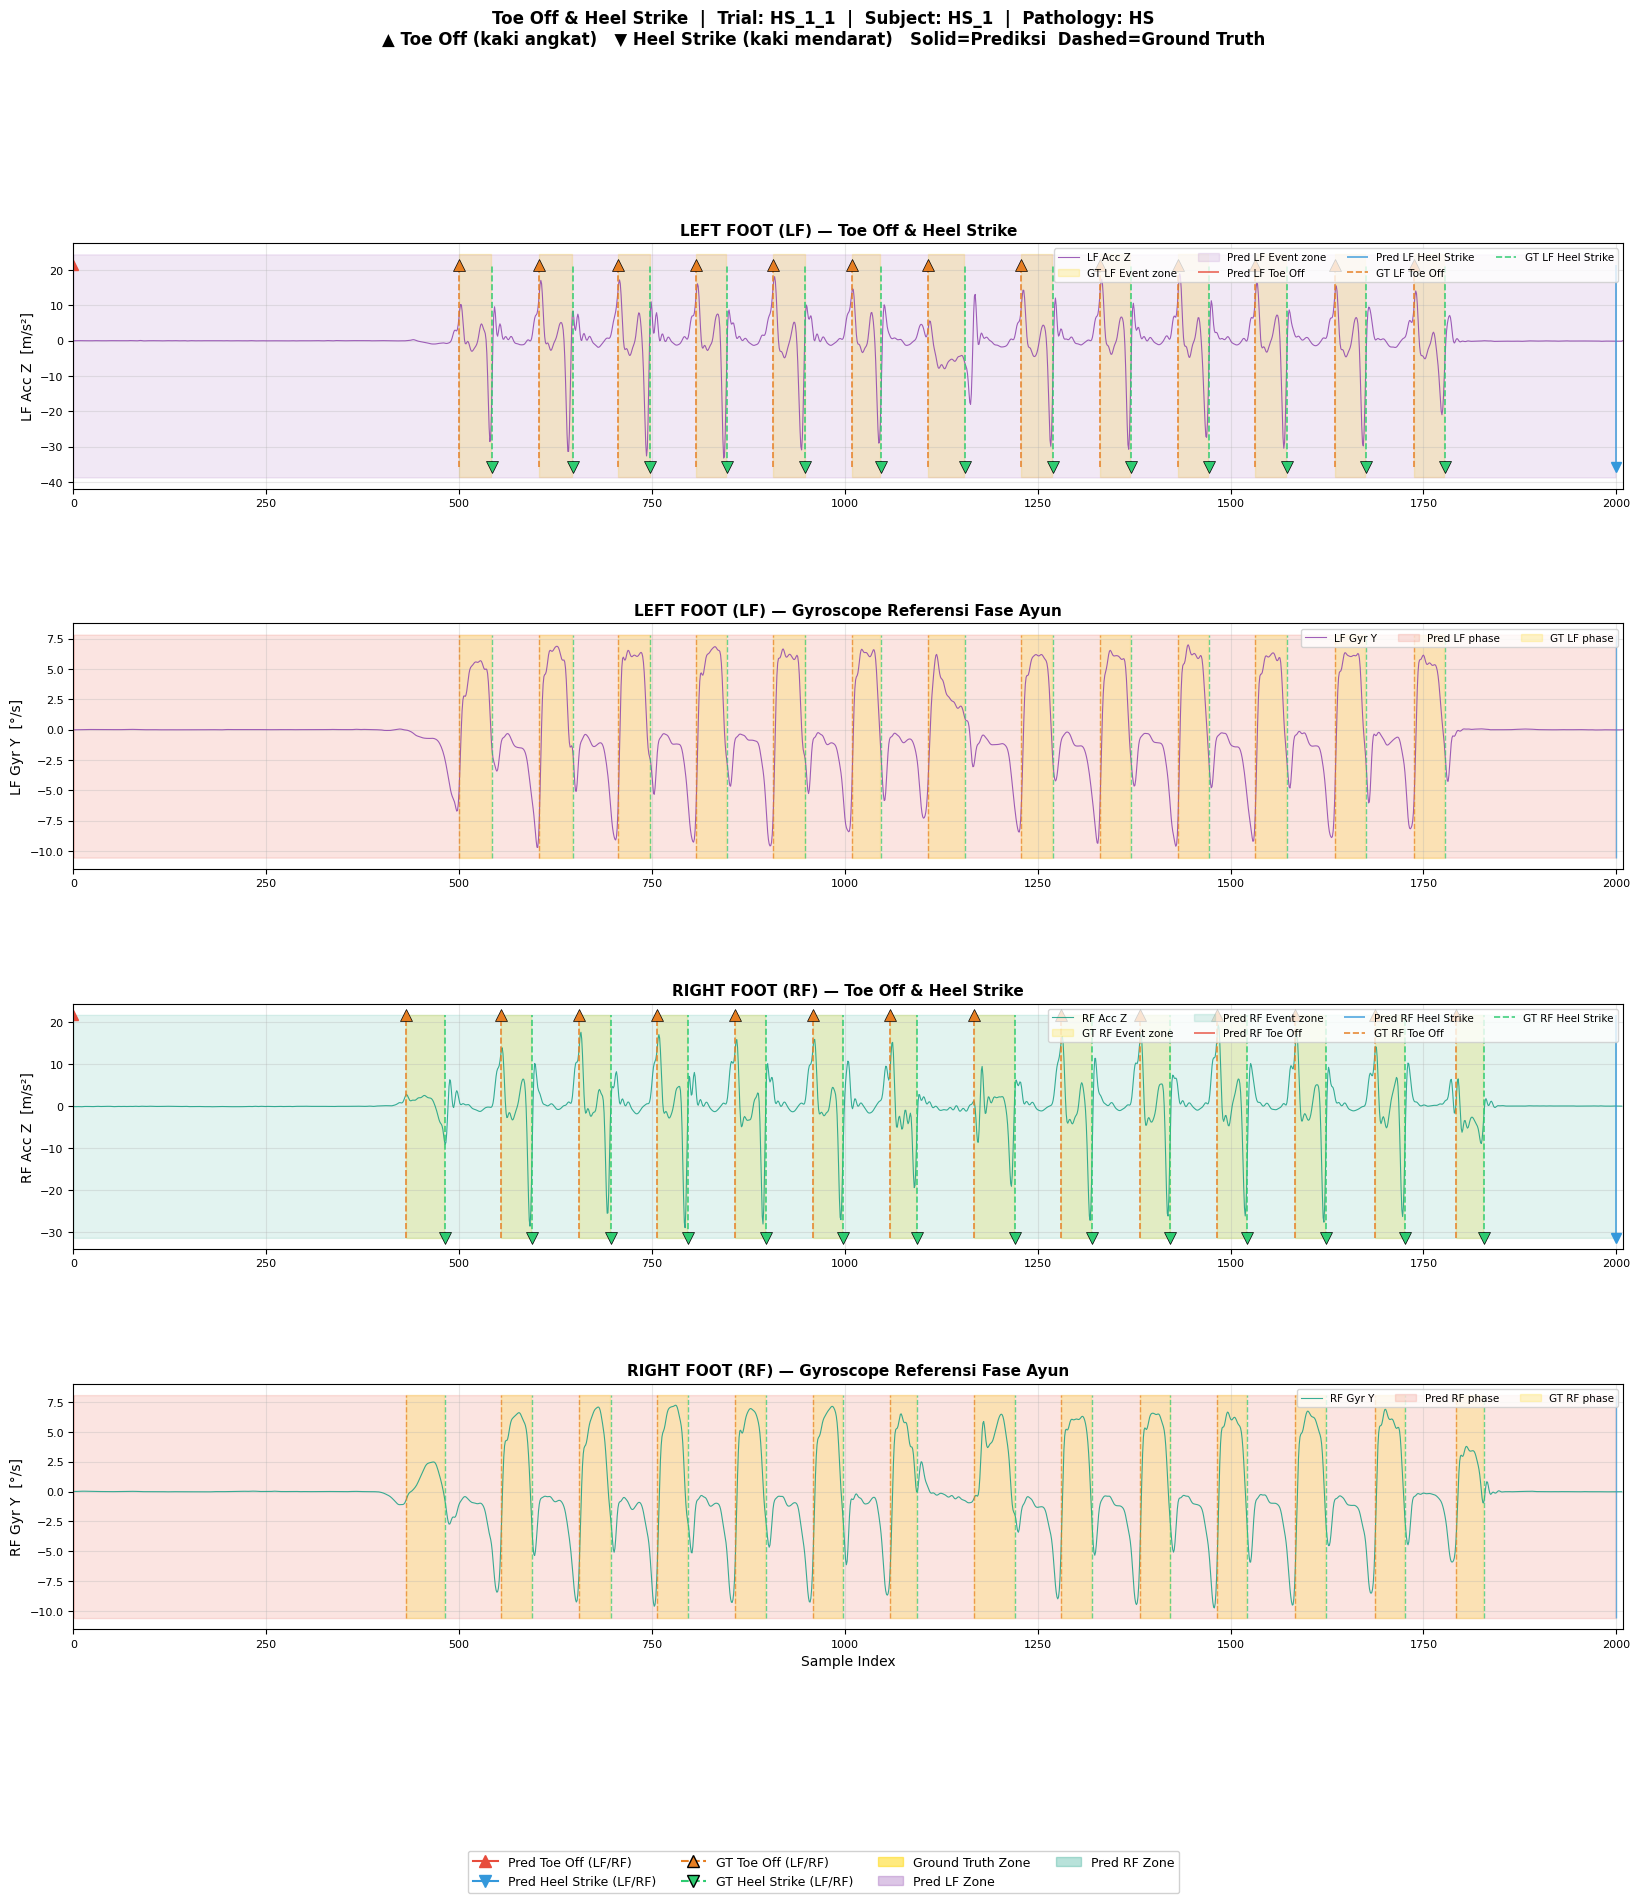


✅ Gambar disimpan: viz_TO_HS_trial_0.png

      Foot   Type              GT  Pred
  ✗  LF     Toe Off           13     1  (Δ=-12)
  ✗  LF     Heel Strike       13     1  (Δ=-12)
  ✗  RF     Toe Off           14     1  (Δ=-13)
  ✗  RF     Heel Strike       14     1  (Δ=-13)


In [26]:
"""
=============================================================
 VISUALISASI TOE OFF & HEEL STRIKE — LF dan RF
=============================================================
Paste ke dalam cell baru di notebook Anda.
Pastikan variabel berikut sudah tersedia dari cell sebelumnya:
  - all_dataset   : list of dict {sensor_matrix, metadata}
  - model         : model Keras yang sudah dilatih
  - WINDOW_SIZE, STRIDE, THRESHOLD (atau gunakan default di bawah)
=============================================================
"""

# ──────────────────────────────────────────────────────────
# CELL: VISUALISASI TOE OFF & HEEL STRIKE (LF, RF)
# ──────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

# ─── CONFIG ────────────────────────────────────────────────
WINDOW_SIZE  = 100    # harus sama dengan saat training
STRIDE       = 50     # harus sama dengan saat training
THRESHOLD    = 0.5    # batas binarisasi prediksi

TRIAL_INDEX  = 0      # ganti untuk trial lain

# Kolom sensor yang digunakan sebagai sinyal referensi
# (sesuaikan dengan indeks di sensor_matrix Anda)
CH_LF_ACC_Z  = 2     # LF_FreeAcc_Z   → referensi untuk LF events
CH_RF_ACC_Z  = 8     # RF_FreeAcc_Z   → referensi untuk RF events
CH_LF_GYR_Y  = 4     # LF_Gyr_Y       → gyro bantu deteksi fase ayun
CH_RF_GYR_Y  = 10    # RF_Gyr_Y       → gyro bantu deteksi fase ayun
# ──────────────────────────────────────────────────────────


# ─── [A] FUNGSI: Deteksi Toe Off & Heel Strike dari mask ──

def extract_to_hs_from_mask(event_mask):
    """
    Dari mask biner (0/1 per sample), ekstrak:
      - Toe Off  : tepi NAIK mask  (0→1) = kaki meninggalkan tanah
      - Heel Strike: tepi TURUN mask (1→0) = kaki menyentuh tanah

    Returns
    -------
    toe_off_samples    : array index sample Toe Off
    heel_strike_samples: array index sample Heel Strike
    """
    diff = np.diff(event_mask.astype(int), prepend=0)
    toe_off_samples     = np.where(diff ==  1)[0]   # rising edge
    heel_strike_samples = np.where(diff == -1)[0]   # falling edge
    return toe_off_samples, heel_strike_samples


def extract_to_hs_from_events(event_list, n_samples):
    """
    Dari daftar interval [start, end]:
      - Toe Off  = nilai start setiap interval
      - Heel Strike = nilai end setiap interval

    Returns
    -------
    to_samples : array index Toe Off
    hs_samples : array index Heel Strike
    """
    to_samples = []
    hs_samples = []
    for ev in event_list:
        s = max(0, int(ev[0]))
        e = min(n_samples - 1, int(ev[1]))
        to_samples.append(s)
        hs_samples.append(e)
    return np.array(to_samples), np.array(hs_samples)


def intervals_to_mask(events, n_samples):
    """Konversi list [start,end] ke mask biner per sample."""
    mask = np.zeros(n_samples, dtype=int)
    for ev in events:
        s, e = max(0, int(ev[0])), min(n_samples, int(ev[1]))
        mask[s:e] = 1
    return mask


def windows_to_mask(binary_arr, n_samples, ws=WINDOW_SIZE, st=STRIDE):
    """Konversi label biner per-window ke mask per sample (OR vote)."""
    mask = np.zeros(n_samples, dtype=int)
    for i, v in enumerate(binary_arr):
        if v == 1:
            s = i * st
            mask[s:min(s + ws, n_samples)] = 1
    return mask


# ─── [B] AMBIL DATA & PREDIKSI ─────────────────────────────

trial         = all_dataset[TRIAL_INDEX]
sensor_matrix = trial['sensor_matrix']
meta          = trial['metadata']
N             = len(sensor_matrix)
t             = np.arange(N)

gt_left_events  = meta.get('left_gait_events',  [])
gt_right_events = meta.get('right_gait_events', [])

print("=" * 60)
print(f"Trial     : {meta.get('trial_id', '?')}")
print(f"Subject   : {meta.get('subject', '?')}")
print(f"Pathology : {meta.get('pathology', '?')}")
print(f"N samples : {N}")
print(f"GT Left   : {len(gt_left_events)} events")
print(f"GT Right  : {len(gt_right_events)} events")
print("=" * 60)

# Sliding-window prediction
seqs = np.array(
    [sensor_matrix[i:i + WINDOW_SIZE] for i in range(0, N - WINDOW_SIZE, STRIDE)],
    dtype=np.float32
)
prob_left, prob_right = model.predict(seqs, verbose=0)
prob_left  = prob_left.flatten()
prob_right = prob_right.flatten()
pred_left_bin  = (prob_left  > THRESHOLD).astype(int)
pred_right_bin = (prob_right > THRESHOLD).astype(int)

# Mask per sample
pred_lm = windows_to_mask(pred_left_bin,  N)
pred_rm = windows_to_mask(pred_right_bin, N)
gt_lm   = intervals_to_mask(gt_left_events,  N)
gt_rm   = intervals_to_mask(gt_right_events, N)

# Toe Off & Heel Strike dari prediksi (tepi mask)
pred_lf_to, pred_lf_hs = extract_to_hs_from_mask(pred_lm)
pred_rf_to, pred_rf_hs = extract_to_hs_from_mask(pred_rm)

# Toe Off & Heel Strike dari Ground Truth
gt_lf_to, gt_lf_hs = extract_to_hs_from_events(gt_left_events,  N)
gt_rf_to, gt_rf_hs = extract_to_hs_from_events(gt_right_events, N)

print(f"\n[LF] Prediksi — Toe Off: {len(pred_lf_to)}, Heel Strike: {len(pred_lf_hs)}")
print(f"[LF] GT       — Toe Off: {len(gt_lf_to)},   Heel Strike: {len(gt_lf_hs)}")
print(f"[RF] Prediksi — Toe Off: {len(pred_rf_to)}, Heel Strike: {len(pred_rf_hs)}")
print(f"[RF] GT       — Toe Off: {len(gt_rf_to)},   Heel Strike: {len(gt_rf_hs)}")


# ─── [C] VISUALISASI ───────────────────────────────────────

fig = plt.figure(figsize=(20, 18))
gs  = GridSpec(4, 1, figure=fig, hspace=0.55)

# Warna
CLR_TO_PRED  = '#e74c3c'   # merah  → Toe Off prediksi
CLR_HS_PRED  = '#3498db'   # biru   → Heel Strike prediksi
CLR_TO_GT    = '#e67e22'   # oranye → Toe Off GT
CLR_HS_GT    = '#2ecc71'   # hijau  → Heel Strike GT
CLR_SIG_LF   = '#8e44ad'   # ungu   → sinyal LF
CLR_SIG_RF   = '#16a085'   # teal   → sinyal RF

sub = meta.get('subject', '?')
path = meta.get('pathology', '?')
tid  = meta.get('trial_id', '?')
fig.suptitle(
    f"Toe Off & Heel Strike  |  Trial: {tid}  |  Subject: {sub}  |  Pathology: {path}\n"
    f"▲ Toe Off (kaki angkat)   ▼ Heel Strike (kaki mendarat)   "
    f"Solid=Prediksi  Dashed=Ground Truth",
    fontsize=12, fontweight='bold', y=1.01
)

# ── SUBPLOT 1: LF Accelerometer + event markers ──────────
ax1 = fig.add_subplot(gs[0])
sig_lf = sensor_matrix[:, CH_LF_ACC_Z]
ax1.plot(t, sig_lf, color=CLR_SIG_LF, linewidth=0.8, alpha=0.85, label='LF Acc Z')

ymin, ymax = ax1.get_ylim()
dy = (ymax - ymin) * 0.05

# Zona event LF (background shading)
ax1.fill_between(t, ymin - dy, ymax + dy,
                 where=(gt_lm == 1),
                 color='gold', alpha=0.20, label='GT LF Event zone')
ax1.fill_between(t, ymin - dy, ymax + dy,
                 where=(pred_lm == 1),
                 color=CLR_SIG_LF, alpha=0.12, label='Pred LF Event zone')

# Marker: Prediksi Toe Off LF  (▲ merah solid)
ax1.vlines(pred_lf_to, ymin, ymax, colors=CLR_TO_PRED,
           linewidth=1.2, linestyle='-', alpha=0.85, label='Pred LF Toe Off')
ax1.plot(pred_lf_to, np.full_like(pred_lf_to, ymax, dtype=float),
         marker='^', color=CLR_TO_PRED, markersize=7, linestyle='None')

# Marker: Prediksi Heel Strike LF  (▼ biru solid)
ax1.vlines(pred_lf_hs, ymin, ymax, colors=CLR_HS_PRED,
           linewidth=1.2, linestyle='-', alpha=0.85, label='Pred LF Heel Strike')
ax1.plot(pred_lf_hs, np.full_like(pred_lf_hs, ymin, dtype=float),
         marker='v', color=CLR_HS_PRED, markersize=7, linestyle='None')

# Marker: GT Toe Off LF  (▲ oranye dashed)
if len(gt_lf_to):
    ax1.vlines(gt_lf_to, ymin, ymax, colors=CLR_TO_GT,
               linewidth=1.2, linestyle='--', alpha=0.9, label='GT LF Toe Off')
    ax1.plot(gt_lf_to, np.full_like(gt_lf_to, ymax, dtype=float),
             marker='^', color=CLR_TO_GT, markersize=8, linestyle='None',
             markeredgecolor='black', markeredgewidth=0.5)

# Marker: GT Heel Strike LF  (▼ hijau dashed)
if len(gt_lf_hs):
    ax1.vlines(gt_lf_hs, ymin, ymax, colors=CLR_HS_GT,
               linewidth=1.2, linestyle='--', alpha=0.9, label='GT LF Heel Strike')
    ax1.plot(gt_lf_hs, np.full_like(gt_lf_hs, ymin, dtype=float),
             marker='v', color=CLR_HS_GT, markersize=8, linestyle='None',
             markeredgecolor='black', markeredgewidth=0.5)

ax1.set_ylabel('LF Acc Z  [m/s²]', fontsize=10)
ax1.set_title('LEFT FOOT (LF) — Toe Off & Heel Strike', fontsize=11, fontweight='bold')
ax1.set_xlim(0, N)
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=8)
ax1.legend(loc='upper right', fontsize=7.5, ncol=4)


# ── SUBPLOT 2: LF Gyroscope (fase ayun) ──────────────────
ax2 = fig.add_subplot(gs[1])
if sensor_matrix.shape[1] > CH_LF_GYR_Y:
    sig_lf_gyr = sensor_matrix[:, CH_LF_GYR_Y]
    ax2.plot(t, sig_lf_gyr, color=CLR_SIG_LF, linewidth=0.8, alpha=0.85,
             label='LF Gyr Y')
    ymin2, ymax2 = ax2.get_ylim()
    ax2.fill_between(t, ymin2, ymax2, where=(pred_lm == 1),
                     color=CLR_TO_PRED, alpha=0.15, label='Pred LF phase')
    ax2.fill_between(t, ymin2, ymax2, where=(gt_lm == 1),
                     color='gold', alpha=0.20, label='GT LF phase')
    ax2.vlines(pred_lf_to, ymin2, ymax2, colors=CLR_TO_PRED,
               linewidth=1.0, linestyle='-', alpha=0.7)
    ax2.vlines(pred_lf_hs, ymin2, ymax2, colors=CLR_HS_PRED,
               linewidth=1.0, linestyle='-', alpha=0.7)
    if len(gt_lf_to):
        ax2.vlines(gt_lf_to, ymin2, ymax2, colors=CLR_TO_GT,
                   linewidth=1.0, linestyle='--', alpha=0.7)
    if len(gt_lf_hs):
        ax2.vlines(gt_lf_hs, ymin2, ymax2, colors=CLR_HS_GT,
                   linewidth=1.0, linestyle='--', alpha=0.7)
    ax2.set_ylabel('LF Gyr Y  [°/s]', fontsize=10)
else:
    ax2.text(0.5, 0.5, 'Kolom LF Gyr Y tidak tersedia',
             ha='center', va='center', transform=ax2.transAxes, fontsize=10)

ax2.set_title('LEFT FOOT (LF) — Gyroscope Referensi Fase Ayun', fontsize=11, fontweight='bold')
ax2.set_xlim(0, N)
ax2.grid(True, alpha=0.3)
ax2.tick_params(labelsize=8)
ax2.legend(loc='upper right', fontsize=7.5, ncol=3)


# ── SUBPLOT 3: RF Accelerometer + event markers ──────────
ax3 = fig.add_subplot(gs[2])
sig_rf = sensor_matrix[:, CH_RF_ACC_Z]
ax3.plot(t, sig_rf, color=CLR_SIG_RF, linewidth=0.8, alpha=0.85, label='RF Acc Z')

ymin3, ymax3 = ax3.get_ylim()

ax3.fill_between(t, ymin3, ymax3, where=(gt_rm == 1),
                 color='gold', alpha=0.20, label='GT RF Event zone')
ax3.fill_between(t, ymin3, ymax3, where=(pred_rm == 1),
                 color=CLR_SIG_RF, alpha=0.12, label='Pred RF Event zone')

ax3.vlines(pred_rf_to, ymin3, ymax3, colors=CLR_TO_PRED,
           linewidth=1.2, linestyle='-', alpha=0.85, label='Pred RF Toe Off')
ax3.plot(pred_rf_to, np.full_like(pred_rf_to, ymax3, dtype=float),
         marker='^', color=CLR_TO_PRED, markersize=7, linestyle='None')

ax3.vlines(pred_rf_hs, ymin3, ymax3, colors=CLR_HS_PRED,
           linewidth=1.2, linestyle='-', alpha=0.85, label='Pred RF Heel Strike')
ax3.plot(pred_rf_hs, np.full_like(pred_rf_hs, ymin3, dtype=float),
         marker='v', color=CLR_HS_PRED, markersize=7, linestyle='None')

if len(gt_rf_to):
    ax3.vlines(gt_rf_to, ymin3, ymax3, colors=CLR_TO_GT,
               linewidth=1.2, linestyle='--', alpha=0.9, label='GT RF Toe Off')
    ax3.plot(gt_rf_to, np.full_like(gt_rf_to, ymax3, dtype=float),
             marker='^', color=CLR_TO_GT, markersize=8, linestyle='None',
             markeredgecolor='black', markeredgewidth=0.5)

if len(gt_rf_hs):
    ax3.vlines(gt_rf_hs, ymin3, ymax3, colors=CLR_HS_GT,
               linewidth=1.2, linestyle='--', alpha=0.9, label='GT RF Heel Strike')
    ax3.plot(gt_rf_hs, np.full_like(gt_rf_hs, ymin3, dtype=float),
             marker='v', color=CLR_HS_GT, markersize=8, linestyle='None',
             markeredgecolor='black', markeredgewidth=0.5)

ax3.set_ylabel('RF Acc Z  [m/s²]', fontsize=10)
ax3.set_title('RIGHT FOOT (RF) — Toe Off & Heel Strike', fontsize=11, fontweight='bold')
ax3.set_xlim(0, N)
ax3.grid(True, alpha=0.3)
ax3.tick_params(labelsize=8)
ax3.legend(loc='upper right', fontsize=7.5, ncol=4)


# ── SUBPLOT 4: RF Gyroscope ───────────────────────────────
ax4 = fig.add_subplot(gs[3])
if sensor_matrix.shape[1] > CH_RF_GYR_Y:
    sig_rf_gyr = sensor_matrix[:, CH_RF_GYR_Y]
    ax4.plot(t, sig_rf_gyr, color=CLR_SIG_RF, linewidth=0.8, alpha=0.85,
             label='RF Gyr Y')
    ymin4, ymax4 = ax4.get_ylim()
    ax4.fill_between(t, ymin4, ymax4, where=(pred_rm == 1),
                     color=CLR_TO_PRED, alpha=0.15, label='Pred RF phase')
    ax4.fill_between(t, ymin4, ymax4, where=(gt_rm == 1),
                     color='gold', alpha=0.20, label='GT RF phase')
    ax4.vlines(pred_rf_to, ymin4, ymax4, colors=CLR_TO_PRED,
               linewidth=1.0, linestyle='-', alpha=0.7)
    ax4.vlines(pred_rf_hs, ymin4, ymax4, colors=CLR_HS_PRED,
               linewidth=1.0, linestyle='-', alpha=0.7)
    if len(gt_rf_to):
        ax4.vlines(gt_rf_to, ymin4, ymax4, colors=CLR_TO_GT,
                   linewidth=1.0, linestyle='--', alpha=0.7)
    if len(gt_rf_hs):
        ax4.vlines(gt_rf_hs, ymin4, ymax4, colors=CLR_HS_GT,
                   linewidth=1.0, linestyle='--', alpha=0.7)
    ax4.set_ylabel('RF Gyr Y  [°/s]', fontsize=10)
else:
    ax4.text(0.5, 0.5, 'Kolom RF Gyr Y tidak tersedia',
             ha='center', va='center', transform=ax4.transAxes, fontsize=10)

ax4.set_title('RIGHT FOOT (RF) — Gyroscope Referensi Fase Ayun', fontsize=11, fontweight='bold')
ax4.set_xlabel('Sample Index', fontsize=10)
ax4.set_xlim(0, N)
ax4.grid(True, alpha=0.3)
ax4.tick_params(labelsize=8)
ax4.legend(loc='upper right', fontsize=7.5, ncol=3)


# ── LEGEND GLOBAL ─────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker='^', color=CLR_TO_PRED, markersize=9,
           linestyle='-', linewidth=1.5, label='Pred Toe Off (LF/RF)'),
    Line2D([0], [0], marker='v', color=CLR_HS_PRED, markersize=9,
           linestyle='-', linewidth=1.5, label='Pred Heel Strike (LF/RF)'),
    Line2D([0], [0], marker='^', color=CLR_TO_GT,   markersize=9,
           linestyle='--', linewidth=1.5, label='GT Toe Off (LF/RF)',
           markeredgecolor='black'),
    Line2D([0], [0], marker='v', color=CLR_HS_GT,   markersize=9,
           linestyle='--', linewidth=1.5, label='GT Heel Strike (LF/RF)',
           markeredgecolor='black'),
    mpatches.Patch(color='gold',      alpha=0.5, label='Ground Truth Zone'),
    mpatches.Patch(color=CLR_SIG_LF,  alpha=0.3, label='Pred LF Zone'),
    mpatches.Patch(color=CLR_SIG_RF,  alpha=0.3, label='Pred RF Zone'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=4, fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
save_path = f"viz_TO_HS_trial_{TRIAL_INDEX}.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Gambar disimpan: {save_path}")


# ─── [D] RINGKASAN EVENT TABLE ─────────────────────────────
print("\n" + "=" * 65)
print(f"{'':5} {'Foot':<6} {'Type':<14} {'GT':>5} {'Pred':>5}")
print("=" * 65)
rows = [
    ("LF", "Toe Off",      len(gt_lf_to), len(pred_lf_to)),
    ("LF", "Heel Strike",  len(gt_lf_hs), len(pred_lf_hs)),
    ("RF", "Toe Off",      len(gt_rf_to), len(pred_rf_to)),
    ("RF", "Heel Strike",  len(gt_rf_hs), len(pred_rf_hs)),
]
for foot, etype, gt_n, pred_n in rows:
    diff_n = pred_n - gt_n
    flag   = "✓" if abs(diff_n) <= 2 else "⚠" if abs(diff_n) <= 5 else "✗"
    print(f"  {flag}  {foot:<6} {etype:<14} {gt_n:>5} {pred_n:>5}  (Δ={diff_n:+d})")
print("=" * 65)


Trial     : HS_1_1
Subject   : HS_1
Pathology : HS
N samples : 2009
GT Left   : 13 events
GT Right  : 14 events

[LF] Prediksi — Toe Off: 1, Heel Strike: 1
[LF] GT       — Toe Off: 13,   Heel Strike: 13
[RF] Prediksi — Toe Off: 1, Heel Strike: 1
[RF] GT       — Toe Off: 14,   Heel Strike: 14


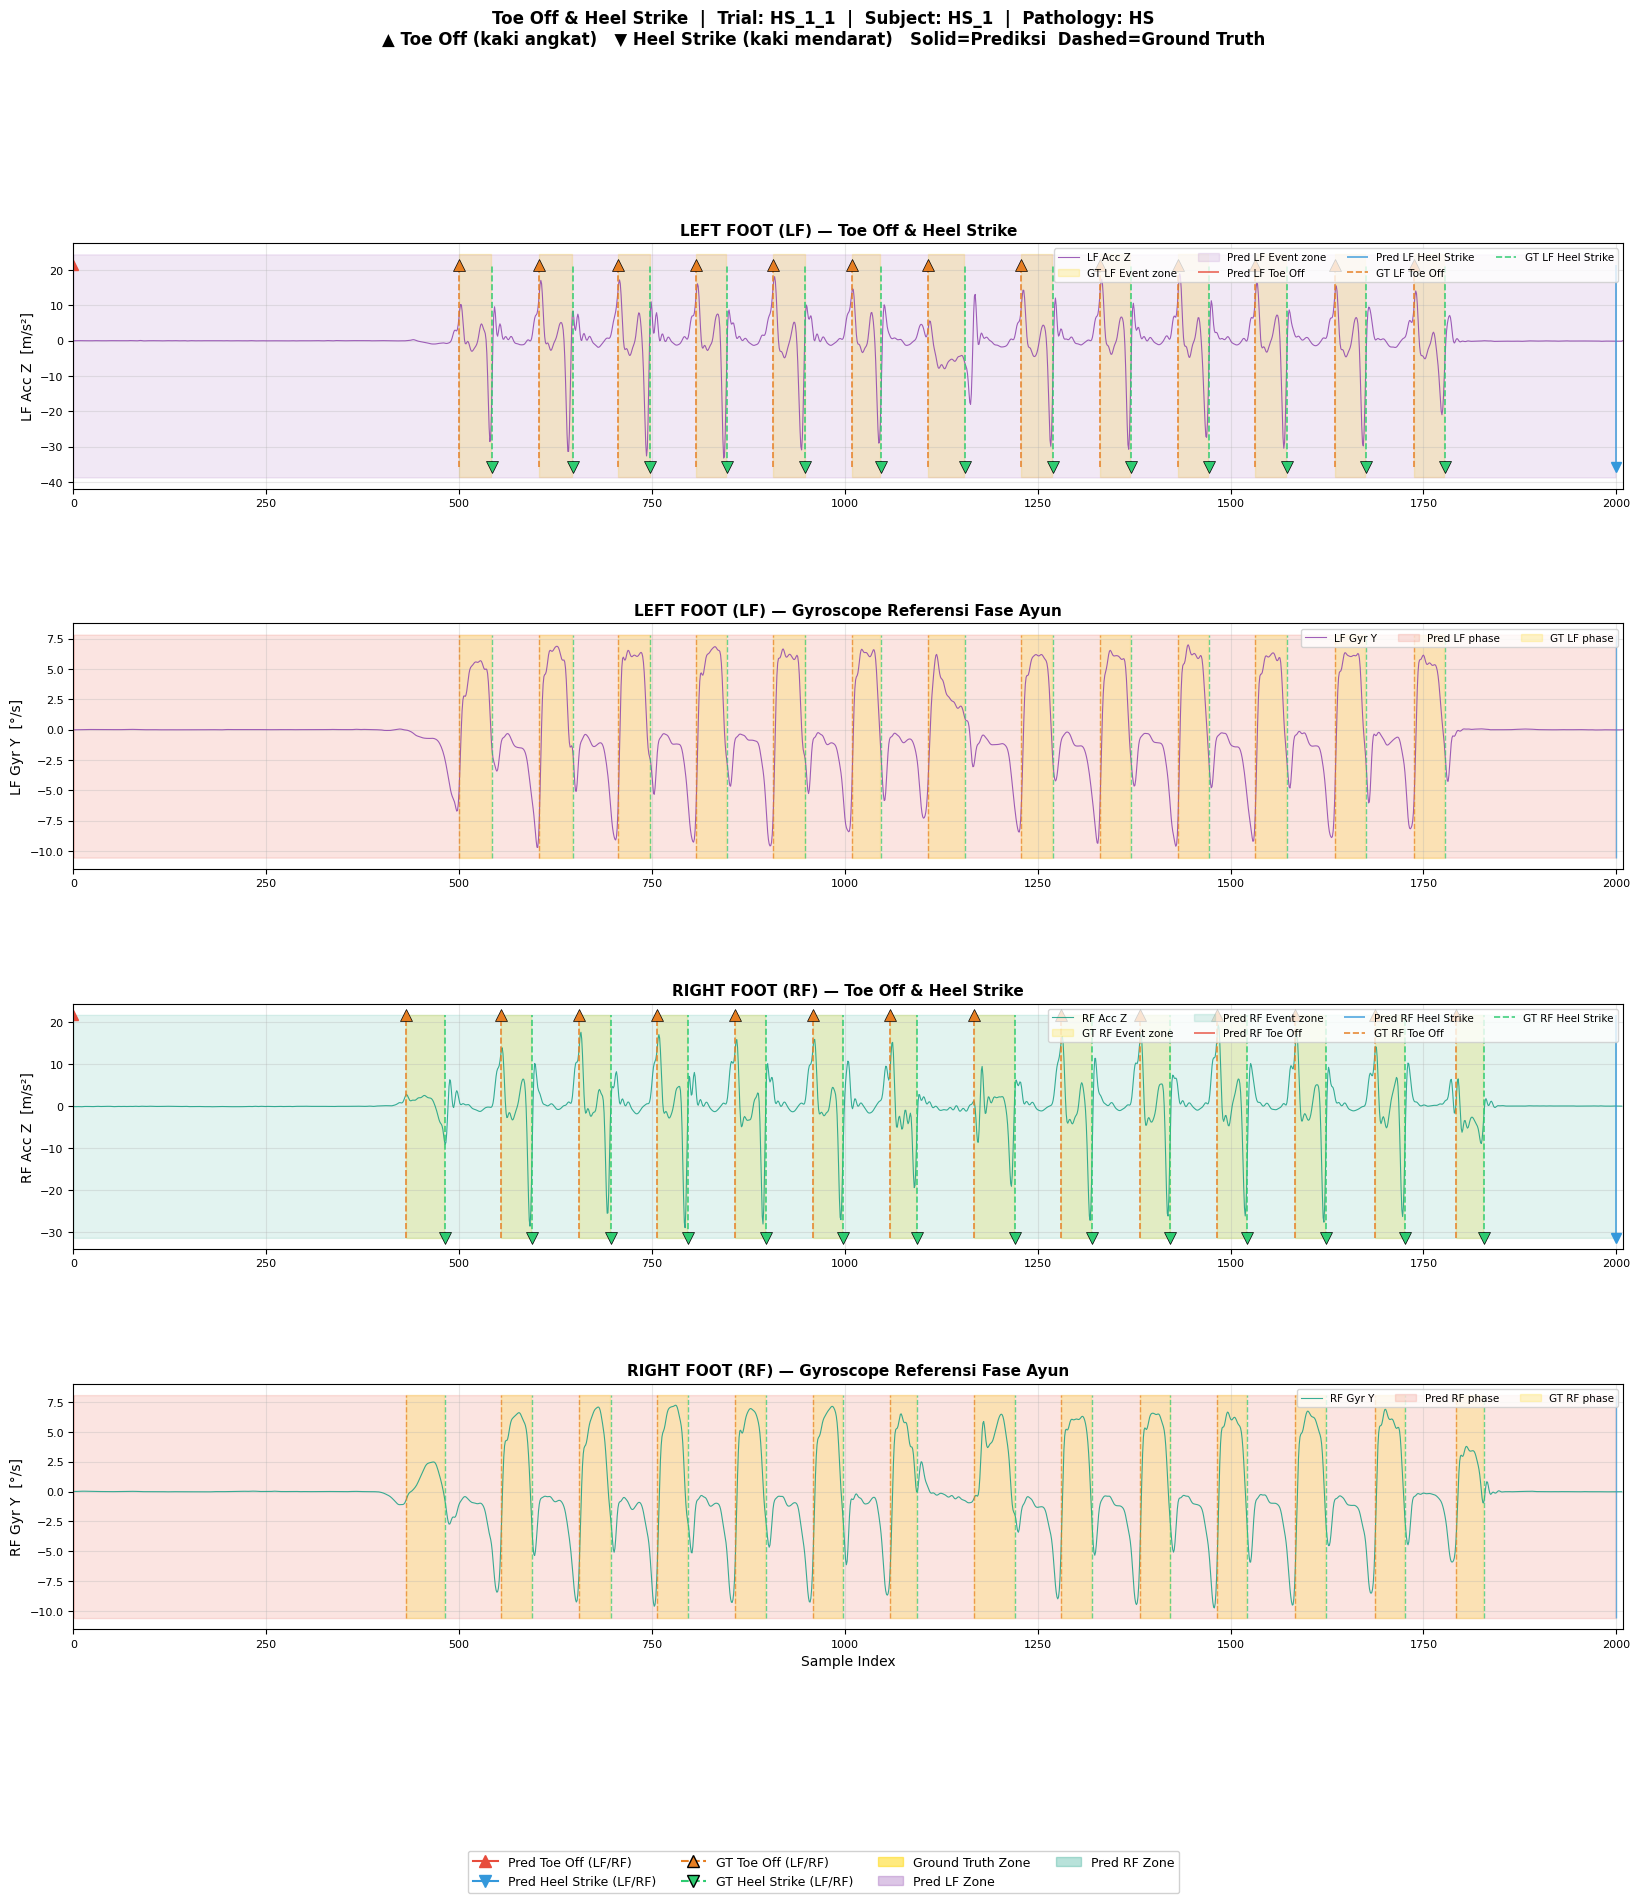


✅ Gambar disimpan: viz_TO_HS_trial_0.png

      Foot   Type              GT  Pred
  ✗  LF     Toe Off           13     1  (Δ=-12)
  ✗  LF     Heel Strike       13     1  (Δ=-12)
  ✗  RF     Toe Off           14     1  (Δ=-13)
  ✗  RF     Heel Strike       14     1  (Δ=-13)

  PREDIKSI MODEL — Index Gait Event

  leftGaitEvents  (LF) (1 events):
  #    [start, end]          Toe Off  Heel Strike   Durasi
  -------------------------------------------------------
  1    [    0,  1999]              0         2000     2000 smp

  rightGaitEvents (RF) (1 events):
  #    [start, end]          Toe Off  Heel Strike   Durasi
  -------------------------------------------------------
  1    [    0,  1999]              0         2000     2000 smp

  GROUND TRUTH — Index Gait Event

  leftGaitEvents  (LF) (13 events):
  #    [start, end]          Toe Off  Heel Strike   Durasi
  -------------------------------------------------------
  1    [  500,   542]            500          543       43 smp
  2 

In [27]:
"""
=============================================================
 VISUALISASI TOE OFF & HEEL STRIKE — LF dan RF
=============================================================
Paste ke dalam cell baru di notebook Anda.
Pastikan variabel berikut sudah tersedia dari cell sebelumnya:
  - all_dataset   : list of dict {sensor_matrix, metadata}
  - model         : model Keras yang sudah dilatih
  - WINDOW_SIZE, STRIDE, THRESHOLD (atau gunakan default di bawah)
=============================================================
"""

# ──────────────────────────────────────────────────────────
# CELL: VISUALISASI TOE OFF & HEEL STRIKE (LF, RF)
# ──────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

# ─── CONFIG ────────────────────────────────────────────────
WINDOW_SIZE  = 100    # harus sama dengan saat training
STRIDE       = 50     # harus sama dengan saat training
THRESHOLD    = 0.5    # batas binarisasi prediksi

TRIAL_INDEX  = 0      # ganti untuk trial lain

# Kolom sensor yang digunakan sebagai sinyal referensi
# (sesuaikan dengan indeks di sensor_matrix Anda)
CH_LF_ACC_Z  = 2     # LF_FreeAcc_Z   → referensi untuk LF events
CH_RF_ACC_Z  = 8     # RF_FreeAcc_Z   → referensi untuk RF events
CH_LF_GYR_Y  = 4     # LF_Gyr_Y       → gyro bantu deteksi fase ayun
CH_RF_GYR_Y  = 10    # RF_Gyr_Y       → gyro bantu deteksi fase ayun
# ──────────────────────────────────────────────────────────


# ─── [A] FUNGSI: Deteksi Toe Off & Heel Strike dari mask ──

def extract_to_hs_from_mask(event_mask):
    """
    Dari mask biner (0/1 per sample), ekstrak:
      - Toe Off  : tepi NAIK mask  (0→1) = kaki meninggalkan tanah
      - Heel Strike: tepi TURUN mask (1→0) = kaki menyentuh tanah

    Returns
    -------
    toe_off_samples    : array index sample Toe Off
    heel_strike_samples: array index sample Heel Strike
    """
    diff = np.diff(event_mask.astype(int), prepend=0)
    toe_off_samples     = np.where(diff ==  1)[0]   # rising edge
    heel_strike_samples = np.where(diff == -1)[0]   # falling edge
    return toe_off_samples, heel_strike_samples


def extract_to_hs_from_events(event_list, n_samples):
    """
    Dari daftar interval [start, end]:
      - Toe Off  = nilai start setiap interval
      - Heel Strike = nilai end setiap interval

    Returns
    -------
    to_samples : array index Toe Off
    hs_samples : array index Heel Strike
    """
    to_samples = []
    hs_samples = []
    for ev in event_list:
        s = max(0, int(ev[0]))
        e = min(n_samples - 1, int(ev[1]))
        to_samples.append(s)
        hs_samples.append(e)
    return np.array(to_samples), np.array(hs_samples)


def intervals_to_mask(events, n_samples):
    """Konversi list [start,end] ke mask biner per sample."""
    mask = np.zeros(n_samples, dtype=int)
    for ev in events:
        s, e = max(0, int(ev[0])), min(n_samples, int(ev[1]))
        mask[s:e] = 1
    return mask


def windows_to_mask(binary_arr, n_samples, ws=WINDOW_SIZE, st=STRIDE):
    """Konversi label biner per-window ke mask per sample (OR vote)."""
    mask = np.zeros(n_samples, dtype=int)
    for i, v in enumerate(binary_arr):
        if v == 1:
            s = i * st
            mask[s:min(s + ws, n_samples)] = 1
    return mask


# ─── [B] AMBIL DATA & PREDIKSI ─────────────────────────────

trial         = all_dataset[TRIAL_INDEX]
sensor_matrix = trial['sensor_matrix']
meta          = trial['metadata']
N             = len(sensor_matrix)
t             = np.arange(N)

gt_left_events  = meta.get('left_gait_events',  [])
gt_right_events = meta.get('right_gait_events', [])

print("=" * 60)
print(f"Trial     : {meta.get('trial_id', '?')}")
print(f"Subject   : {meta.get('subject', '?')}")
print(f"Pathology : {meta.get('pathology', '?')}")
print(f"N samples : {N}")
print(f"GT Left   : {len(gt_left_events)} events")
print(f"GT Right  : {len(gt_right_events)} events")
print("=" * 60)

# Sliding-window prediction
seqs = np.array(
    [sensor_matrix[i:i + WINDOW_SIZE] for i in range(0, N - WINDOW_SIZE, STRIDE)],
    dtype=np.float32
)
prob_left, prob_right = model.predict(seqs, verbose=0)
prob_left  = prob_left.flatten()
prob_right = prob_right.flatten()
pred_left_bin  = (prob_left  > THRESHOLD).astype(int)
pred_right_bin = (prob_right > THRESHOLD).astype(int)

# Mask per sample
pred_lm = windows_to_mask(pred_left_bin,  N)
pred_rm = windows_to_mask(pred_right_bin, N)
gt_lm   = intervals_to_mask(gt_left_events,  N)
gt_rm   = intervals_to_mask(gt_right_events, N)

# Toe Off & Heel Strike dari prediksi (tepi mask)
pred_lf_to, pred_lf_hs = extract_to_hs_from_mask(pred_lm)
pred_rf_to, pred_rf_hs = extract_to_hs_from_mask(pred_rm)

# Toe Off & Heel Strike dari Ground Truth
gt_lf_to, gt_lf_hs = extract_to_hs_from_events(gt_left_events,  N)
gt_rf_to, gt_rf_hs = extract_to_hs_from_events(gt_right_events, N)

print(f"\n[LF] Prediksi — Toe Off: {len(pred_lf_to)}, Heel Strike: {len(pred_lf_hs)}")
print(f"[LF] GT       — Toe Off: {len(gt_lf_to)},   Heel Strike: {len(gt_lf_hs)}")
print(f"[RF] Prediksi — Toe Off: {len(pred_rf_to)}, Heel Strike: {len(pred_rf_hs)}")
print(f"[RF] GT       — Toe Off: {len(gt_rf_to)},   Heel Strike: {len(gt_rf_hs)}")


# ─── [C] VISUALISASI ───────────────────────────────────────

fig = plt.figure(figsize=(20, 18))
gs  = GridSpec(4, 1, figure=fig, hspace=0.55)

# Warna
CLR_TO_PRED  = '#e74c3c'   # merah  → Toe Off prediksi
CLR_HS_PRED  = '#3498db'   # biru   → Heel Strike prediksi
CLR_TO_GT    = '#e67e22'   # oranye → Toe Off GT
CLR_HS_GT    = '#2ecc71'   # hijau  → Heel Strike GT
CLR_SIG_LF   = '#8e44ad'   # ungu   → sinyal LF
CLR_SIG_RF   = '#16a085'   # teal   → sinyal RF

sub = meta.get('subject', '?')
path = meta.get('pathology', '?')
tid  = meta.get('trial_id', '?')
fig.suptitle(
    f"Toe Off & Heel Strike  |  Trial: {tid}  |  Subject: {sub}  |  Pathology: {path}\n"
    f"▲ Toe Off (kaki angkat)   ▼ Heel Strike (kaki mendarat)   "
    f"Solid=Prediksi  Dashed=Ground Truth",
    fontsize=12, fontweight='bold', y=1.01
)

# ── SUBPLOT 1: LF Accelerometer + event markers ──────────
ax1 = fig.add_subplot(gs[0])
sig_lf = sensor_matrix[:, CH_LF_ACC_Z]
ax1.plot(t, sig_lf, color=CLR_SIG_LF, linewidth=0.8, alpha=0.85, label='LF Acc Z')

ymin, ymax = ax1.get_ylim()
dy = (ymax - ymin) * 0.05

# Zona event LF (background shading)
ax1.fill_between(t, ymin - dy, ymax + dy,
                 where=(gt_lm == 1),
                 color='gold', alpha=0.20, label='GT LF Event zone')
ax1.fill_between(t, ymin - dy, ymax + dy,
                 where=(pred_lm == 1),
                 color=CLR_SIG_LF, alpha=0.12, label='Pred LF Event zone')

# Marker: Prediksi Toe Off LF  (▲ merah solid)
ax1.vlines(pred_lf_to, ymin, ymax, colors=CLR_TO_PRED,
           linewidth=1.2, linestyle='-', alpha=0.85, label='Pred LF Toe Off')
ax1.plot(pred_lf_to, np.full_like(pred_lf_to, ymax, dtype=float),
         marker='^', color=CLR_TO_PRED, markersize=7, linestyle='None')

# Marker: Prediksi Heel Strike LF  (▼ biru solid)
ax1.vlines(pred_lf_hs, ymin, ymax, colors=CLR_HS_PRED,
           linewidth=1.2, linestyle='-', alpha=0.85, label='Pred LF Heel Strike')
ax1.plot(pred_lf_hs, np.full_like(pred_lf_hs, ymin, dtype=float),
         marker='v', color=CLR_HS_PRED, markersize=7, linestyle='None')

# Marker: GT Toe Off LF  (▲ oranye dashed)
if len(gt_lf_to):
    ax1.vlines(gt_lf_to, ymin, ymax, colors=CLR_TO_GT,
               linewidth=1.2, linestyle='--', alpha=0.9, label='GT LF Toe Off')
    ax1.plot(gt_lf_to, np.full_like(gt_lf_to, ymax, dtype=float),
             marker='^', color=CLR_TO_GT, markersize=8, linestyle='None',
             markeredgecolor='black', markeredgewidth=0.5)

# Marker: GT Heel Strike LF  (▼ hijau dashed)
if len(gt_lf_hs):
    ax1.vlines(gt_lf_hs, ymin, ymax, colors=CLR_HS_GT,
               linewidth=1.2, linestyle='--', alpha=0.9, label='GT LF Heel Strike')
    ax1.plot(gt_lf_hs, np.full_like(gt_lf_hs, ymin, dtype=float),
             marker='v', color=CLR_HS_GT, markersize=8, linestyle='None',
             markeredgecolor='black', markeredgewidth=0.5)

ax1.set_ylabel('LF Acc Z  [m/s²]', fontsize=10)
ax1.set_title('LEFT FOOT (LF) — Toe Off & Heel Strike', fontsize=11, fontweight='bold')
ax1.set_xlim(0, N)
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=8)
ax1.legend(loc='upper right', fontsize=7.5, ncol=4)


# ── SUBPLOT 2: LF Gyroscope (fase ayun) ──────────────────
ax2 = fig.add_subplot(gs[1])
if sensor_matrix.shape[1] > CH_LF_GYR_Y:
    sig_lf_gyr = sensor_matrix[:, CH_LF_GYR_Y]
    ax2.plot(t, sig_lf_gyr, color=CLR_SIG_LF, linewidth=0.8, alpha=0.85,
             label='LF Gyr Y')
    ymin2, ymax2 = ax2.get_ylim()
    ax2.fill_between(t, ymin2, ymax2, where=(pred_lm == 1),
                     color=CLR_TO_PRED, alpha=0.15, label='Pred LF phase')
    ax2.fill_between(t, ymin2, ymax2, where=(gt_lm == 1),
                     color='gold', alpha=0.20, label='GT LF phase')
    ax2.vlines(pred_lf_to, ymin2, ymax2, colors=CLR_TO_PRED,
               linewidth=1.0, linestyle='-', alpha=0.7)
    ax2.vlines(pred_lf_hs, ymin2, ymax2, colors=CLR_HS_PRED,
               linewidth=1.0, linestyle='-', alpha=0.7)
    if len(gt_lf_to):
        ax2.vlines(gt_lf_to, ymin2, ymax2, colors=CLR_TO_GT,
                   linewidth=1.0, linestyle='--', alpha=0.7)
    if len(gt_lf_hs):
        ax2.vlines(gt_lf_hs, ymin2, ymax2, colors=CLR_HS_GT,
                   linewidth=1.0, linestyle='--', alpha=0.7)
    ax2.set_ylabel('LF Gyr Y  [°/s]', fontsize=10)
else:
    ax2.text(0.5, 0.5, 'Kolom LF Gyr Y tidak tersedia',
             ha='center', va='center', transform=ax2.transAxes, fontsize=10)

ax2.set_title('LEFT FOOT (LF) — Gyroscope Referensi Fase Ayun', fontsize=11, fontweight='bold')
ax2.set_xlim(0, N)
ax2.grid(True, alpha=0.3)
ax2.tick_params(labelsize=8)
ax2.legend(loc='upper right', fontsize=7.5, ncol=3)


# ── SUBPLOT 3: RF Accelerometer + event markers ──────────
ax3 = fig.add_subplot(gs[2])
sig_rf = sensor_matrix[:, CH_RF_ACC_Z]
ax3.plot(t, sig_rf, color=CLR_SIG_RF, linewidth=0.8, alpha=0.85, label='RF Acc Z')

ymin3, ymax3 = ax3.get_ylim()

ax3.fill_between(t, ymin3, ymax3, where=(gt_rm == 1),
                 color='gold', alpha=0.20, label='GT RF Event zone')
ax3.fill_between(t, ymin3, ymax3, where=(pred_rm == 1),
                 color=CLR_SIG_RF, alpha=0.12, label='Pred RF Event zone')

ax3.vlines(pred_rf_to, ymin3, ymax3, colors=CLR_TO_PRED,
           linewidth=1.2, linestyle='-', alpha=0.85, label='Pred RF Toe Off')
ax3.plot(pred_rf_to, np.full_like(pred_rf_to, ymax3, dtype=float),
         marker='^', color=CLR_TO_PRED, markersize=7, linestyle='None')

ax3.vlines(pred_rf_hs, ymin3, ymax3, colors=CLR_HS_PRED,
           linewidth=1.2, linestyle='-', alpha=0.85, label='Pred RF Heel Strike')
ax3.plot(pred_rf_hs, np.full_like(pred_rf_hs, ymin3, dtype=float),
         marker='v', color=CLR_HS_PRED, markersize=7, linestyle='None')

if len(gt_rf_to):
    ax3.vlines(gt_rf_to, ymin3, ymax3, colors=CLR_TO_GT,
               linewidth=1.2, linestyle='--', alpha=0.9, label='GT RF Toe Off')
    ax3.plot(gt_rf_to, np.full_like(gt_rf_to, ymax3, dtype=float),
             marker='^', color=CLR_TO_GT, markersize=8, linestyle='None',
             markeredgecolor='black', markeredgewidth=0.5)

if len(gt_rf_hs):
    ax3.vlines(gt_rf_hs, ymin3, ymax3, colors=CLR_HS_GT,
               linewidth=1.2, linestyle='--', alpha=0.9, label='GT RF Heel Strike')
    ax3.plot(gt_rf_hs, np.full_like(gt_rf_hs, ymin3, dtype=float),
             marker='v', color=CLR_HS_GT, markersize=8, linestyle='None',
             markeredgecolor='black', markeredgewidth=0.5)

ax3.set_ylabel('RF Acc Z  [m/s²]', fontsize=10)
ax3.set_title('RIGHT FOOT (RF) — Toe Off & Heel Strike', fontsize=11, fontweight='bold')
ax3.set_xlim(0, N)
ax3.grid(True, alpha=0.3)
ax3.tick_params(labelsize=8)
ax3.legend(loc='upper right', fontsize=7.5, ncol=4)


# ── SUBPLOT 4: RF Gyroscope ───────────────────────────────
ax4 = fig.add_subplot(gs[3])
if sensor_matrix.shape[1] > CH_RF_GYR_Y:
    sig_rf_gyr = sensor_matrix[:, CH_RF_GYR_Y]
    ax4.plot(t, sig_rf_gyr, color=CLR_SIG_RF, linewidth=0.8, alpha=0.85,
             label='RF Gyr Y')
    ymin4, ymax4 = ax4.get_ylim()
    ax4.fill_between(t, ymin4, ymax4, where=(pred_rm == 1),
                     color=CLR_TO_PRED, alpha=0.15, label='Pred RF phase')
    ax4.fill_between(t, ymin4, ymax4, where=(gt_rm == 1),
                     color='gold', alpha=0.20, label='GT RF phase')
    ax4.vlines(pred_rf_to, ymin4, ymax4, colors=CLR_TO_PRED,
               linewidth=1.0, linestyle='-', alpha=0.7)
    ax4.vlines(pred_rf_hs, ymin4, ymax4, colors=CLR_HS_PRED,
               linewidth=1.0, linestyle='-', alpha=0.7)
    if len(gt_rf_to):
        ax4.vlines(gt_rf_to, ymin4, ymax4, colors=CLR_TO_GT,
                   linewidth=1.0, linestyle='--', alpha=0.7)
    if len(gt_rf_hs):
        ax4.vlines(gt_rf_hs, ymin4, ymax4, colors=CLR_HS_GT,
                   linewidth=1.0, linestyle='--', alpha=0.7)
    ax4.set_ylabel('RF Gyr Y  [°/s]', fontsize=10)
else:
    ax4.text(0.5, 0.5, 'Kolom RF Gyr Y tidak tersedia',
             ha='center', va='center', transform=ax4.transAxes, fontsize=10)

ax4.set_title('RIGHT FOOT (RF) — Gyroscope Referensi Fase Ayun', fontsize=11, fontweight='bold')
ax4.set_xlabel('Sample Index', fontsize=10)
ax4.set_xlim(0, N)
ax4.grid(True, alpha=0.3)
ax4.tick_params(labelsize=8)
ax4.legend(loc='upper right', fontsize=7.5, ncol=3)


# ── LEGEND GLOBAL ─────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker='^', color=CLR_TO_PRED, markersize=9,
           linestyle='-', linewidth=1.5, label='Pred Toe Off (LF/RF)'),
    Line2D([0], [0], marker='v', color=CLR_HS_PRED, markersize=9,
           linestyle='-', linewidth=1.5, label='Pred Heel Strike (LF/RF)'),
    Line2D([0], [0], marker='^', color=CLR_TO_GT,   markersize=9,
           linestyle='--', linewidth=1.5, label='GT Toe Off (LF/RF)',
           markeredgecolor='black'),
    Line2D([0], [0], marker='v', color=CLR_HS_GT,   markersize=9,
           linestyle='--', linewidth=1.5, label='GT Heel Strike (LF/RF)',
           markeredgecolor='black'),
    mpatches.Patch(color='gold',      alpha=0.5, label='Ground Truth Zone'),
    mpatches.Patch(color=CLR_SIG_LF,  alpha=0.3, label='Pred LF Zone'),
    mpatches.Patch(color=CLR_SIG_RF,  alpha=0.3, label='Pred RF Zone'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=4, fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
save_path = f"viz_TO_HS_trial_{TRIAL_INDEX}.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Gambar disimpan: {save_path}")


# ─── [D] RINGKASAN EVENT TABLE ─────────────────────────────
print("\n" + "=" * 65)
print(f"{'':5} {'Foot':<6} {'Type':<14} {'GT':>5} {'Pred':>5}")
print("=" * 65)
rows = [
    ("LF", "Toe Off",      len(gt_lf_to), len(pred_lf_to)),
    ("LF", "Heel Strike",  len(gt_lf_hs), len(pred_lf_hs)),
    ("RF", "Toe Off",      len(gt_rf_to), len(pred_rf_to)),
    ("RF", "Heel Strike",  len(gt_rf_hs), len(pred_rf_hs)),
]
for foot, etype, gt_n, pred_n in rows:
    diff_n = pred_n - gt_n
    flag   = "✓" if abs(diff_n) <= 2 else "⚠" if abs(diff_n) <= 5 else "✗"
    print(f"  {flag}  {foot:<6} {etype:<14} {gt_n:>5} {pred_n:>5}  (Δ={diff_n:+d})")
print("=" * 65)


# ─── [E] DETAIL INDEX [start, end] PER GAIT EVENT ─────────
# ── Helper: rekonstruksi interval dari mask ──────────────

def mask_to_intervals(mask):
    """Konversi mask biner ke list [start, end] per segmen aktif."""
    intervals = []
    in_event  = False
    start     = 0
    for i, v in enumerate(mask):
        if v == 1 and not in_event:
            start    = i
            in_event = True
        elif v == 0 and in_event:
            intervals.append([start, i - 1])
            in_event = False
    if in_event:
        intervals.append([start, len(mask) - 1])
    return intervals


pred_left_intervals  = mask_to_intervals(pred_lm)
pred_right_intervals = mask_to_intervals(pred_rm)
gt_left_intervals    = mask_to_intervals(gt_lm)
gt_right_intervals   = mask_to_intervals(gt_rm)

# ── Cetak format leftGaitEvents / rightGaitEvents ───────

def print_event_detail(label, intervals, to_samples, hs_samples):
    """
    Cetak setiap interval [start, end] lengkap dengan:
      - Toe Off  = sample awal interval
      - Heel Strike = sample akhir interval
      - Durasi = end - start + 1 sample
    """
    print(f"\n  {label} ({len(intervals)} events):")
    print(f"  {'#':<4} {'[start, end]':<18} {'Toe Off':>10} {'Heel Strike':>12} {'Durasi':>8}")
    print(f"  {'-'*55}")
    for idx, (s, e) in enumerate(intervals):
        dur = e - s + 1
        # Cari TO & HS terdekat dengan start dan end interval ini
        to_near = to_samples[np.argmin(np.abs(to_samples - s))] if len(to_samples) else s
        hs_near = hs_samples[np.argmin(np.abs(hs_samples - e))] if len(hs_samples) else e
        print(f"  {idx+1:<4} [{s:>5}, {e:>5}]     {to_near:>10}   {hs_near:>10}   {dur:>6} smp")


print("\n" + "=" * 65)
print("  PREDIKSI MODEL — Index Gait Event")
print("=" * 65)
print_event_detail("leftGaitEvents  (LF)", pred_left_intervals,  pred_lf_to, pred_lf_hs)
print_event_detail("rightGaitEvents (RF)", pred_right_intervals, pred_rf_to, pred_rf_hs)

print("\n" + "=" * 65)
print("  GROUND TRUTH — Index Gait Event")
print("=" * 65)
print_event_detail("leftGaitEvents  (LF)", gt_left_intervals,  gt_lf_to, gt_lf_hs)
print_event_detail("rightGaitEvents (RF)", gt_right_intervals, gt_rf_to, gt_rf_hs)

# ── Format ringkas satu baris (copy-paste friendly) ──────

def format_compact(label, intervals):
    pairs = ", ".join(f"[{s}, {e}]" for s, e in intervals)
    print(f'\n  "{label}": {pairs}')

print("\n" + "=" * 65)
print("  FORMAT RINGKAS (copy-paste)")
print("=" * 65)
print("\n  >> PREDIKSI MODEL:")
format_compact("leftGaitEvents",  pred_left_intervals)
format_compact("rightGaitEvents", pred_right_intervals)
print("\n  >> GROUND TRUTH:")
format_compact("leftGaitEvents",  gt_left_intervals)
format_compact("rightGaitEvents", gt_right_intervals)
print("=" * 65)
